In [12]:
import pandas as pd
import numpy as np

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os

BASE = "/content/drive/MyDrive/TCN_Irrigation_Project"

print(os.listdir(BASE))

['Data', 'Processed_Data', 'Models', 'Results', 'Dashboard', 'Research', 'Deployment', 'Digital_Twin', 'System_Logs', 'Backups', 'Notebooks']


In [16]:
import os

print(os.listdir("/content/drive"))
print(os.listdir("/content/drive/MyDrive"))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']
['Vikas kannaujiya Resume (1).pdf', 'vikas aadhar .pdf', 'vikas jati -Compressed.pdf', 'introduction .aac', 'IMG-20240219-WA0007.jpg', 'IMG_20240321_162150.jpg', 'Files', 'Untitled form (3).gform', 'Untitled form (Responses).gsheet', 'Certificate For Archivements ( Robotics club ) (1).pdf', 'Certificate For Archivements ( Robotics club ).pdf', 'Untitled form (File responses) (1)', 'Untitled form (2).gform', 'Untitled form (File responses)', 'Untitled form (1).gform', 'Untitled form.gform', 'B.TECH 2ND YEAR NON CS RESUME .gsheet', 'Screenshot_2025-06-30-10-45-29-142-edit_com.whatsapp.w4b.jpg', 'Smart helmet with accident detection and sos system from Vikas Kannaujiya.pdf', 'IntrotoModernAIUpdate20250910-31-4hfu4d.pdf', 'SIH25036-IDEA-Presentation-AQUAGUARDIANS FINAL.pptx', 'TEAM G.ONE STARTUP- EXPO.pdf', 'Screenshot_2026-02-25-08-10-46-226_com.google.android.apps.nbu.paisa.user.jpg', 'Idea to busines model (2024-25).pdf.gd

In [17]:
print(os.listdir(BASE + "/Data"))

['dataset_9', 'dataset_6', 'dataset_8', 'dataset_7', 'dataset_5', 'dataset_3', 'dataset_4', 'dataset_2', 'dataset_12', 'dataset_11', 'dataset_1', 'dataset_10', 'dataset_14', 'india_weather_25yr.gsheet', 'dataset_weather_india', 'india_weather_25yr.csv', 'india_weather_clean.csv']


In [18]:
import pandas as pd

# Project Base Path
BASE = "/content/drive/MyDrive/TCN_Irrigation_Project"

# ==========================
# NASA Weather Dataset (2001–2025)
# ==========================
# Correctly parse the 'date' column from YYYYMMDD string format
weather = pd.read_csv(f"{BASE}/Data/india_weather_25yr.csv", parse_dates=['date'], date_format='%Y%m%d')

print("=" * 60)
print("NASA Weather Dataset")
print("=" * 60)
print("Shape :", weather.shape)
print("Columns:")
print(weather.columns.tolist())

NASA Weather Dataset
Shape : (167616, 14)
Columns:
['date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2MDEW', 'RH2M', 'PRECTOTCORR', 'WS2M', 'PS', 'ALLSKY_SFC_SW_DWN', 'GWETTOP', 'GWETROOT', 'EVLAND', 'city']


In [19]:
import requests
import pandas as pd
import time

cities = {
    "Lucknow": (26.8467, 80.9462),
    "Delhi": (28.7041, 77.1025),
    "Bhopal": (23.2599, 77.4126),
    "Indore": (22.7196, 75.8577),
    "Kanpur": (26.4499, 80.3319),
    "Ludhiana": (30.9010, 75.8573),
    "Patna": (25.5941, 85.1376),
    "Jaipur": (26.9124, 75.7873),
    "Pune": (18.5204, 73.8567),
    "Nagpur": (21.1458, 79.0882),
    "Hyderabad": (17.3850, 78.4867),
    "Bengaluru": (12.9716, 77.5946),
    "Chennai": (13.0827, 80.2707),
    "Ahmedabad": (23.0225, 72.5714),
    "Guwahati": (26.1445, 91.7362),
    "Bhubaneswar": (20.2961, 85.8245),
    "Amritsar": (31.6340, 74.8723),
    "Varanasi": (25.3176, 82.9739),
}

all_dfs = []

for city, (lat, lon) in cities.items():

    url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters":
            "T2M,"
            "T2M_MAX,"
            "T2M_MIN,"
            "T2MDEW,"
            "RH2M,"
            "PRECTOTCORR,"
            "WS2M,"
            "PS,"
            "ALLSKY_SFC_SW_DWN,"
            "GWETTOP,"
            "GWETROOT,"
            "EVLAND",

        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": "20010101",
        "end": "20260630",
        "format": "JSON"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    pdata = response.json()["properties"]["parameter"]

    dfs = [
        pd.DataFrame.from_dict(v, orient="index", columns=[k])
        for k, v in pdata.items()
    ]

    df_city = pd.concat(dfs, axis=1)

    df_city["city"] = city
    df_city.index.name = "date"

    all_dfs.append(df_city.reset_index())

    print(f"Downloaded : {city}")

    time.sleep(1)

india_weather = pd.concat(all_dfs, ignore_index=True)

save_path = "/content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_25yr.csv"

india_weather.to_csv(save_path, index=False)

print("\nDataset Saved Successfully!")
print("Shape :", india_weather.shape)
print("Saved At :", save_path)
print(india_weather.head())

Downloaded : Lucknow
Downloaded : Delhi
Downloaded : Bhopal
Downloaded : Indore
Downloaded : Kanpur
Downloaded : Ludhiana
Downloaded : Patna
Downloaded : Jaipur
Downloaded : Pune
Downloaded : Nagpur
Downloaded : Hyderabad
Downloaded : Bengaluru
Downloaded : Chennai
Downloaded : Ahmedabad
Downloaded : Guwahati
Downloaded : Bhubaneswar
Downloaded : Amritsar
Downloaded : Varanasi

Dataset Saved Successfully!
Shape : (167616, 14)
Saved At : /content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_25yr.csv
       date    T2M  T2M_MAX  T2M_MIN  T2MDEW   RH2M  PRECTOTCORR  WS2M  \
0  20010101  14.86    19.01    11.38   10.62  76.55         1.04  1.08   
1  20010102  14.82    21.38    10.02    9.70  73.44         0.02  1.27   
2  20010103  14.27    23.19     7.78    5.21  58.97         0.00  1.81   
3  20010104  13.51    22.57     6.84    4.10  55.86         0.00  2.03   
4  20010105  13.53    23.18     6.04    1.00  45.44         0.00  2.06   

       PS  ALLSKY_SFC_SW_DWN  GWETTOP  G

In [20]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_25yr.csv")

print("="*60)
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistics")
print(df.describe())

Dataset Shape
(167616, 14)

Columns
['date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2MDEW', 'RH2M', 'PRECTOTCORR', 'WS2M', 'PS', 'ALLSKY_SFC_SW_DWN', 'GWETTOP', 'GWETROOT', 'EVLAND', 'city']

Data Types
date                   int64
T2M                  float64
T2M_MAX              float64
T2M_MIN              float64
T2MDEW               float64
RH2M                 float64
PRECTOTCORR          float64
WS2M                 float64
PS                   float64
ALLSKY_SFC_SW_DWN    float64
GWETTOP              float64
GWETROOT             float64
EVLAND               float64
city                  object
dtype: object

First 5 Rows
       date    T2M  T2M_MAX  T2M_MIN  T2MDEW   RH2M  PRECTOTCORR  WS2M  \
0  20010101  14.86    19.01    11.38   10.62  76.55         1.04  1.08   
1  20010102  14.82    21.38    10.02    9.70  73.44         0.02  1.27   
2  20010103  14.27    23.19     7.78    5.21  58.97         0.00  1.81   
3  20010104  13.51    22.57     6.84    4.10  55.86         0.00  2.03   
4

In [21]:
print(df["city"].unique())

print("\nNumber of Cities =", df["city"].nunique())

['Lucknow' 'Delhi' 'Bhopal' 'Indore' 'Kanpur' 'Ludhiana' 'Patna' 'Jaipur'
 'Pune' 'Nagpur' 'Hyderabad' 'Bengaluru' 'Chennai' 'Ahmedabad' 'Guwahati'
 'Bhubaneswar' 'Amritsar' 'Varanasi']

Number of Cities = 18


In [22]:
print("Start Date :", df["date"].min())
print("End Date   :", df["date"].max())

Start Date : 20010101
End Date   : 20260630


In [23]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_25yr.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

# Sort data
df = df.sort_values(["city", "date"]).reset_index(drop=True)

# Replace NASA missing values
df.replace(-999, np.nan, inplace=True)

print("Missing Values Before Filling")
print(df.isnull().sum())

# Fill missing values city-wise
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

df[numeric_cols] = df.groupby("city")[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

# Fill remaining missing values
df.fillna(method="bfill", inplace=True)
df.fillna(method="ffill", inplace=True)

print("\nMissing Values After Filling")
print(df.isnull().sum())

print("\nDataset Shape")
print(df.shape)

Missing Values Before Filling
date                  0
T2M                   0
T2M_MAX               0
T2M_MIN               0
T2MDEW                0
RH2M                  0
PRECTOTCORR           0
WS2M                  0
PS                    0
ALLSKY_SFC_SW_DWN    18
GWETTOP               0
GWETROOT              0
EVLAND                0
city                  0
dtype: int64

Missing Values After Filling
date                 0
T2M                  0
T2M_MAX              0
T2M_MIN              0
T2MDEW               0
RH2M                 0
PRECTOTCORR          0
WS2M                 0
PS                   0
ALLSKY_SFC_SW_DWN    0
GWETTOP              0
GWETROOT             0
EVLAND               0
city                 0
dtype: int64

Dataset Shape
(167616, 14)


/tmp/ipykernel_621/1727982569.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)
/tmp/ipykernel_621/1727982569.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [24]:
save_path="/content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_clean.csv"

df.to_csv(save_path,index=False)

print("Saved Successfully")
print(save_path)

Saved Successfully
/content/drive/MyDrive/TCN_Irrigation_Project/Data/india_weather_clean.csv


In [25]:
print(df.describe())

print(df.isnull().sum())

                      date            T2M        T2M_MAX        T2M_MIN  \
count               167616  167616.000000  167616.000000  167616.000000   
mean   2013-09-30 12:00:00      25.719344      32.378540      20.034465   
min    2001-01-01 00:00:00       6.300000      11.150000      -0.970000   
25%    2007-05-17 18:00:00      21.627500      28.260000      15.050000   
50%    2013-09-30 12:00:00      26.200000      31.670000      21.360000   
75%    2020-02-14 06:00:00      29.780000      36.400000      25.230000   
max    2026-06-30 00:00:00      42.290000      50.140000      36.320000   
std                    NaN       6.152609       6.016734       6.546564   

              T2MDEW           RH2M    PRECTOTCORR           WS2M  \
count  167616.000000  167616.000000  167616.000000  167616.000000   
mean       14.127622      56.837539       2.896981       2.115747   
min       -18.990000       4.190000       0.000000       0.180000   
25%         7.390000      37.080000       0.0000

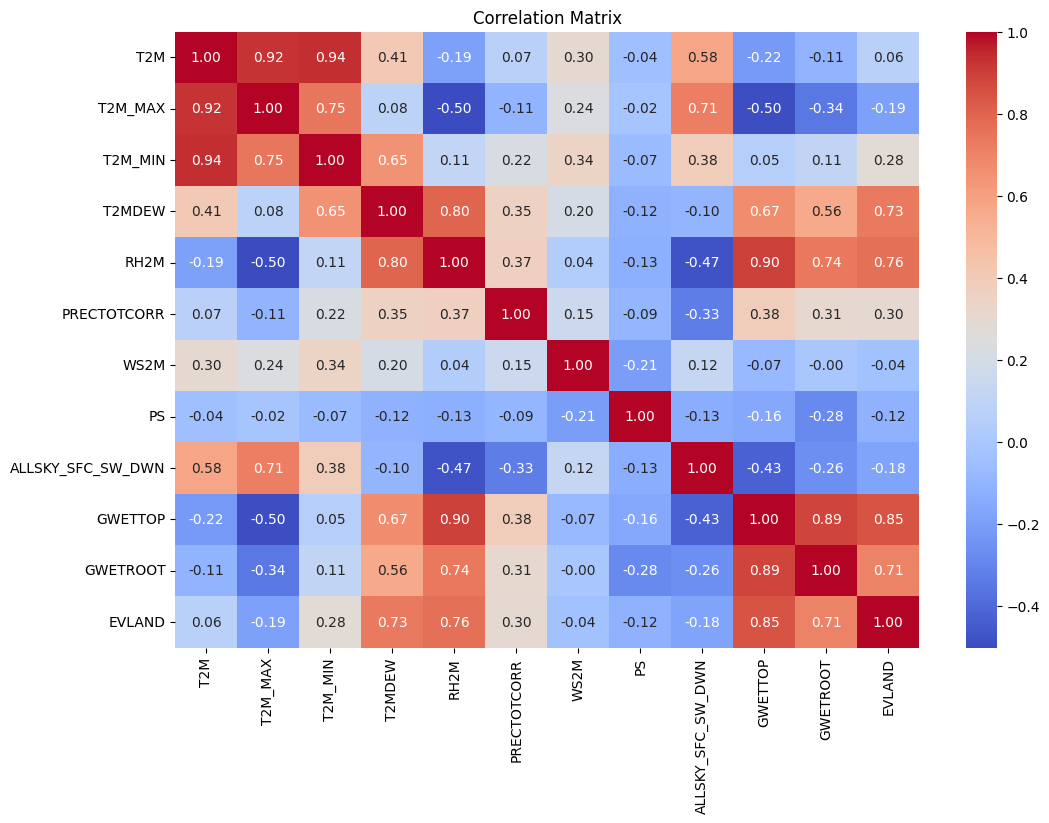

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

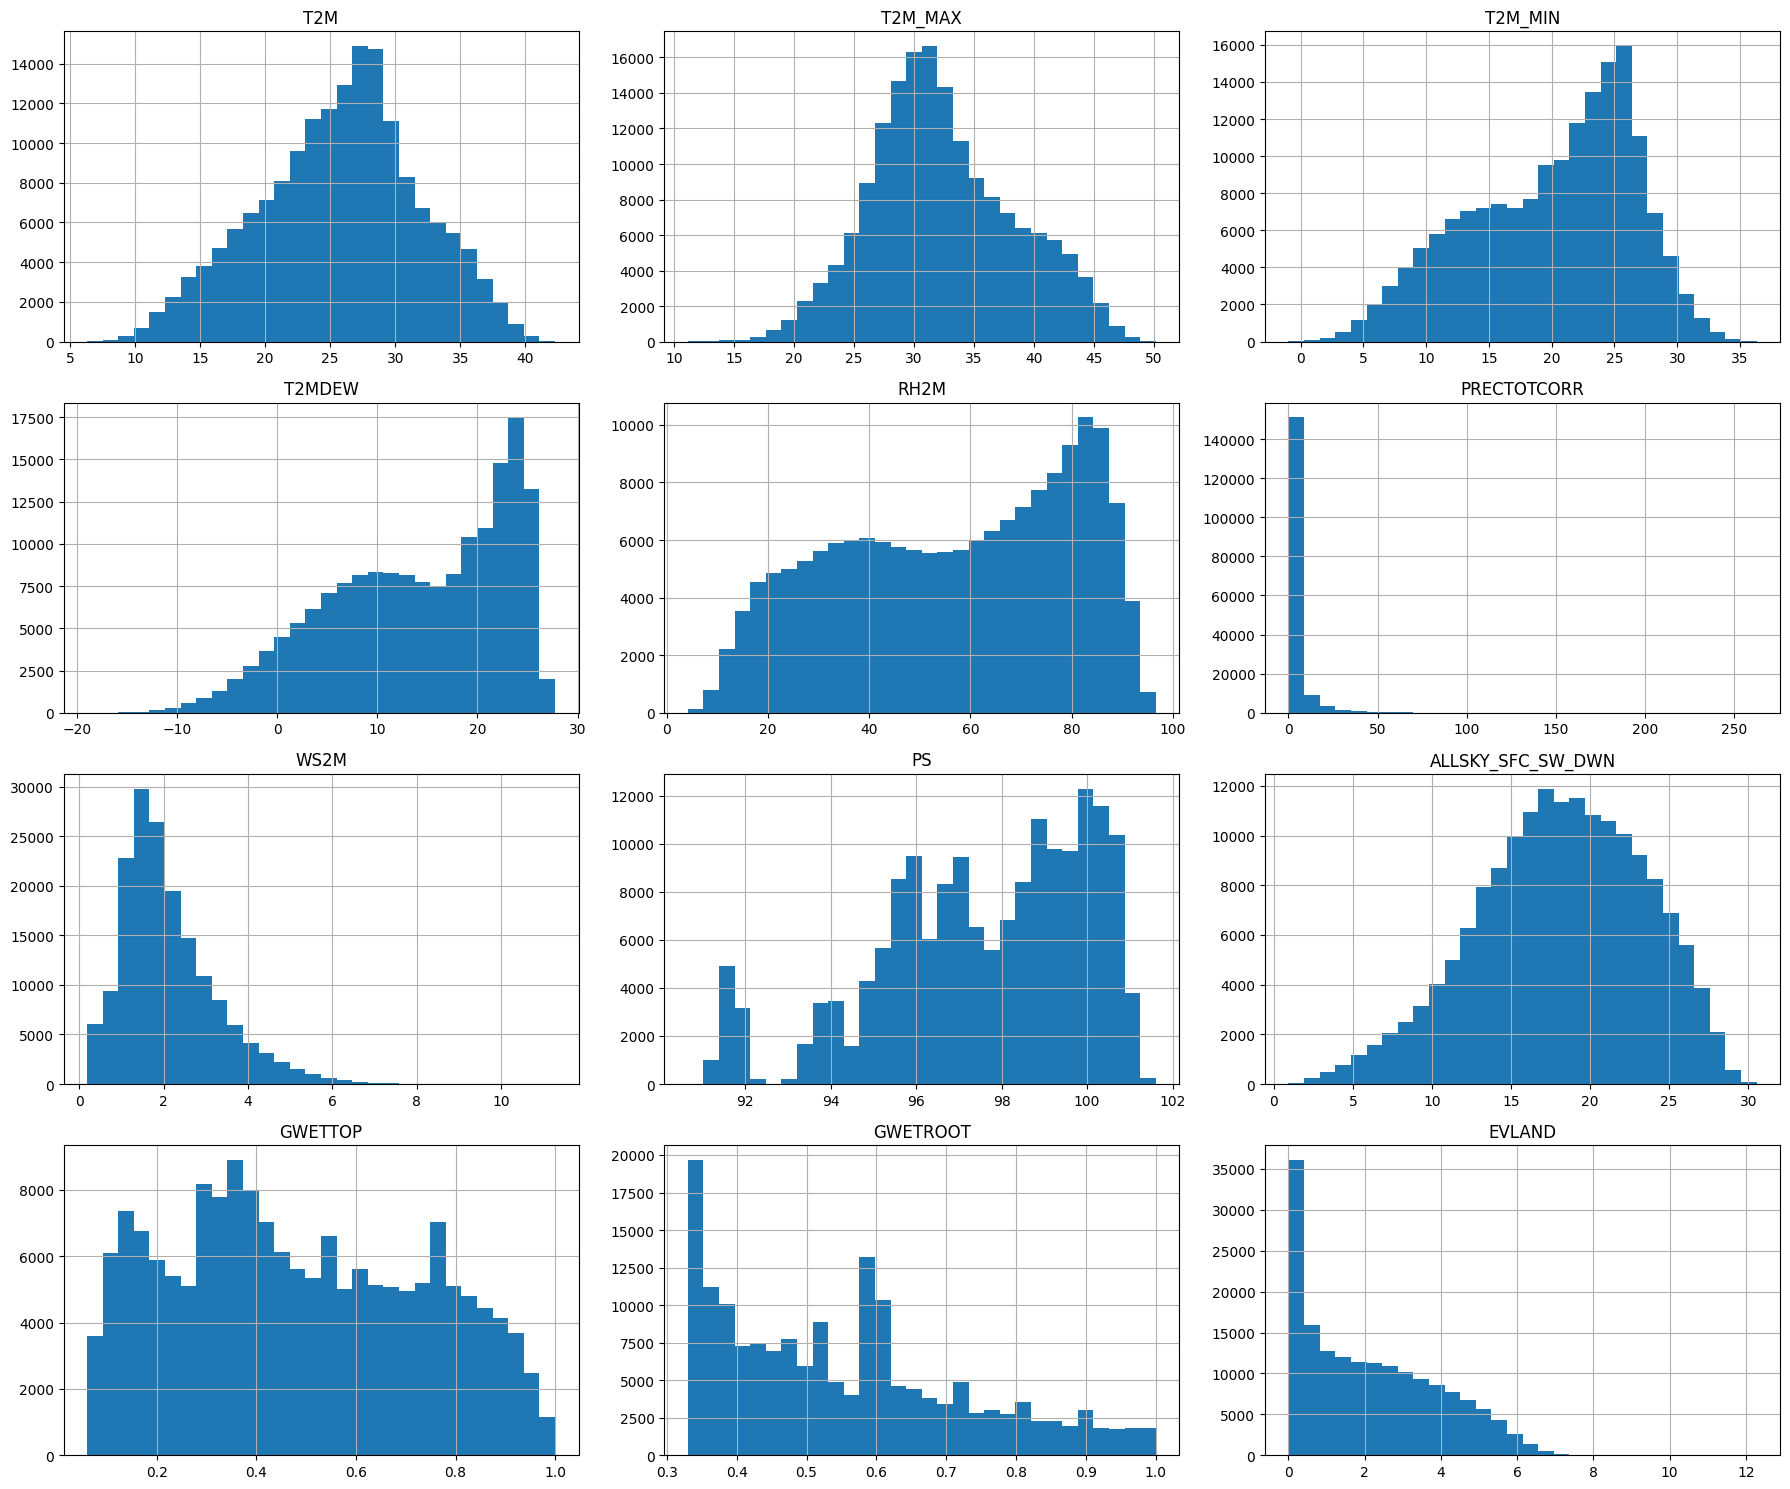

In [27]:
numeric_df.hist(figsize=(18,15), bins=30)

plt.tight_layout()

plt.show()

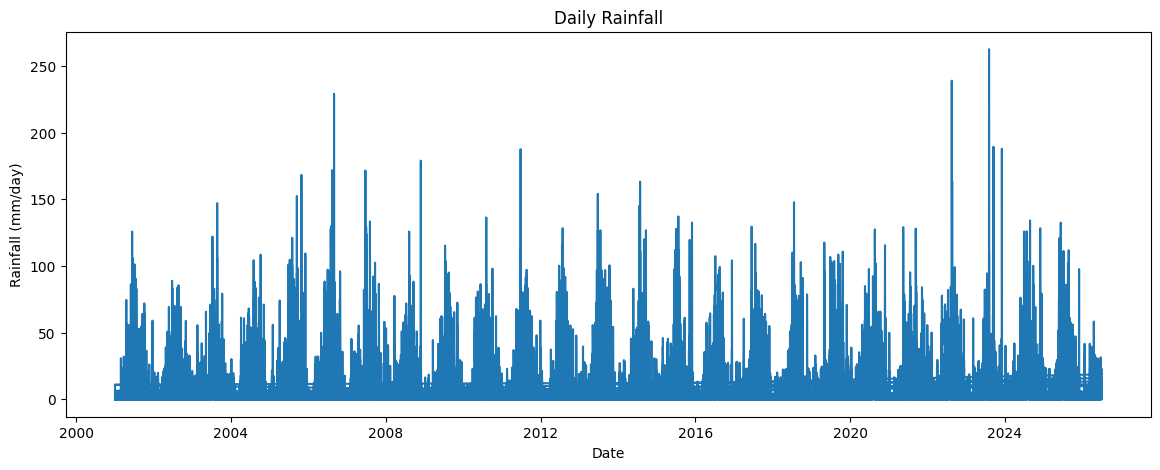

In [28]:
plt.figure(figsize=(14,5))

plt.plot(df["date"], df["PRECTOTCORR"])

plt.title("Daily Rainfall")

plt.xlabel("Date")

plt.ylabel("Rainfall (mm/day)")

plt.show()

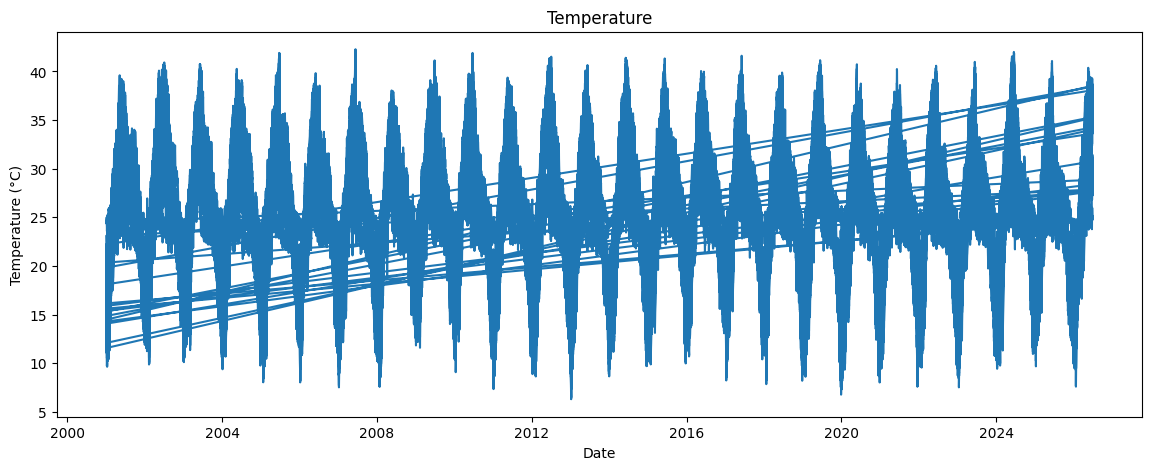

In [29]:
plt.figure(figsize=(14,5))

plt.plot(df["date"], df["T2M"])

plt.title("Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

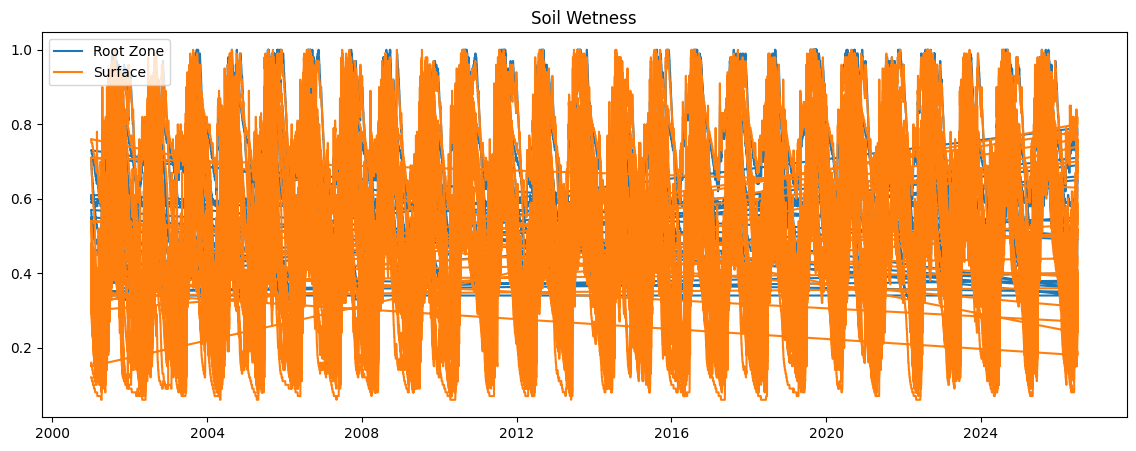

In [30]:
plt.figure(figsize=(14,5))

plt.plot(df["date"], df["GWETROOT"], label="Root Zone")

plt.plot(df["date"], df["GWETTOP"], label="Surface")

plt.legend()

plt.title("Soil Wetness")

plt.show()

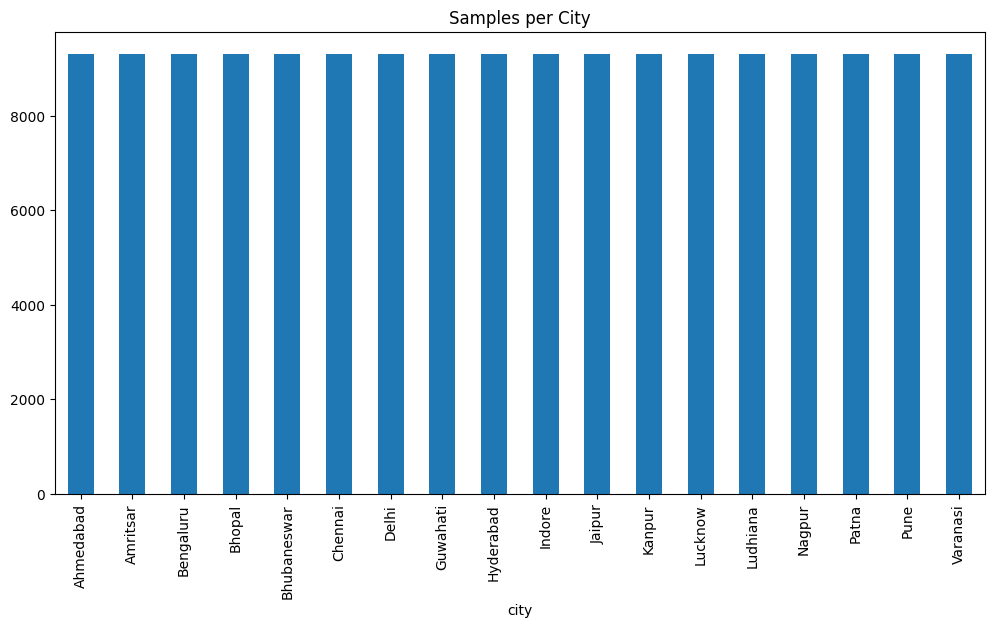

In [31]:
plt.figure(figsize=(12,6))

df["city"].value_counts().plot(kind="bar")

plt.title("Samples per City")

plt.show()

In [32]:
import numpy as np

# Temperature Range
df["TEMP_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

# Day of Year
df["DAY_OF_YEAR"] = df["date"].dt.dayofyear

# Month
df["MONTH"] = df["date"].dt.month

# Year
df["YEAR"] = df["date"].dt.year

In [33]:
df["RAIN_3D"] = df.groupby("city")["PRECTOTCORR"].transform(
    lambda x: x.rolling(3, min_periods=1).sum()
)

df["RAIN_7D"] = df.groupby("city")["PRECTOTCORR"].transform(
    lambda x: x.rolling(7, min_periods=1).sum()
)

df["TEMP_7D"] = df.groupby("city")["T2M"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

df["RH_7D"] = df.groupby("city")["RH2M"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

In [34]:
df["GWETROOT_LAG1"] = df.groupby("city")["GWETROOT"].shift(1)

df["GWETTOP_LAG1"] = df.groupby("city")["GWETTOP"].shift(1)

df["RAIN_LAG1"] = df.groupby("city")["PRECTOTCORR"].shift(1)

In [35]:
df.fillna(method="bfill", inplace=True)
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_621/2360960147.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)
/tmp/ipykernel_621/2360960147.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [36]:
print(df.head())

print(df.shape)

print(df.columns)

        date    T2M  T2M_MAX  T2M_MIN  T2MDEW   RH2M  PRECTOTCORR  WS2M  \
0 2001-01-01  18.64    27.30    11.38   -0.45  29.86         0.02  2.12   
1 2001-01-02  18.04    27.03    10.69    2.16  37.93         0.00  2.15   
2 2001-01-03  18.53    28.56    10.39    0.35  33.22         0.00  2.27   
3 2001-01-04  18.77    29.53    10.51   -1.83  27.61         0.00  2.74   
4 2001-01-05  19.45    30.00    10.71   -2.40  24.96         0.00  2.25   

       PS  ALLSKY_SFC_SW_DWN  ...  DAY_OF_YEAR  MONTH  YEAR RAIN_3D  RAIN_7D  \
0  100.70              16.34  ...            1      1  2001    0.02     0.02   
1  100.96              16.80  ...            2      1  2001    0.02     0.02   
2  101.02              16.58  ...            3      1  2001    0.02     0.02   
3  101.01              17.09  ...            4      1  2001    0.00     0.02   
4  100.95              17.03  ...            5      1  2001    0.00     0.02   

     TEMP_7D   RH_7D  GWETROOT_LAG1  GWETTOP_LAG1  RAIN_LAG1  
0  18

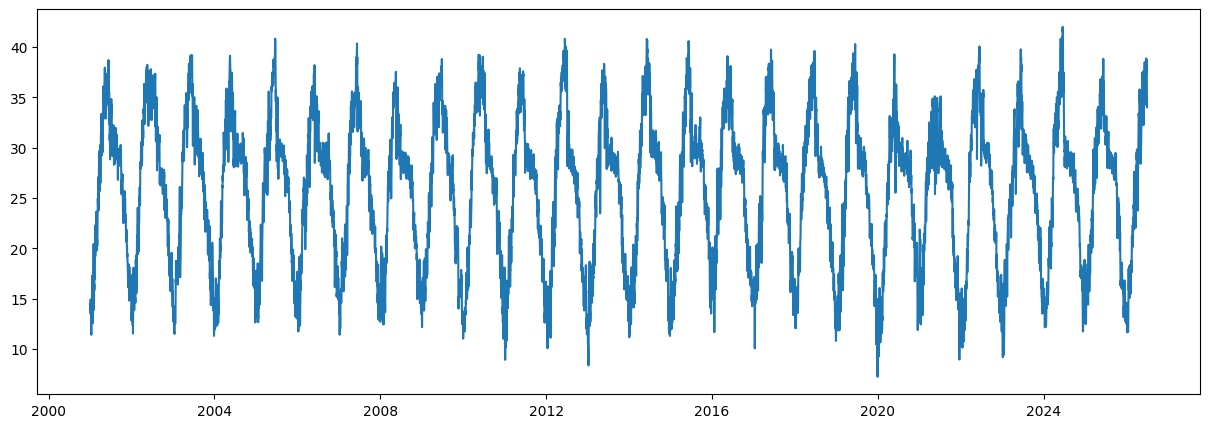

In [37]:
lucknow = df[df["city"]=="Lucknow"]

plt.figure(figsize=(15,5))
plt.plot(lucknow["date"],lucknow["T2M"])
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder

# City ko numeric me convert karenge
le = LabelEncoder()

df["CITY_ID"] = le.fit_transform(df["city"])

In [39]:
FEATURES = [

    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "T2MDEW",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
    "PS",
    "ALLSKY_SFC_SW_DWN",
    "EVLAND",

    "TEMP_RANGE",
    "DAY_OF_YEAR",
    "MONTH",
    "YEAR",

    "RAIN_3D",
    "RAIN_7D",

    "TEMP_7D",
    "RH_7D",

    "GWETROOT_LAG1",
    "GWETTOP_LAG1",
    "RAIN_LAG1",

    "CITY_ID"

]

TARGET = [

    "GWETTOP",
    "GWETROOT"

]

X = df[FEATURES]

Y = df[TARGET]

In [40]:
print("Input Shape :", X.shape)

print("Target Shape :", Y.shape)

print()

print("Input Features")

print(X.columns.tolist())

print()

print("Targets")

print(Y.columns.tolist())

Input Shape : (167616, 22)
Target Shape : (167616, 2)

Input Features
['T2M', 'T2M_MAX', 'T2M_MIN', 'T2MDEW', 'RH2M', 'PRECTOTCORR', 'WS2M', 'PS', 'ALLSKY_SFC_SW_DWN', 'EVLAND', 'TEMP_RANGE', 'DAY_OF_YEAR', 'MONTH', 'YEAR', 'RAIN_3D', 'RAIN_7D', 'TEMP_7D', 'RH_7D', 'GWETROOT_LAG1', 'GWETTOP_LAG1', 'RAIN_LAG1', 'CITY_ID']

Targets
['GWETTOP', 'GWETROOT']


In [41]:
print("Input Shape :", X.shape)

print("Target Shape :", Y.shape)

print()

print("Input Features")

print(X.columns.tolist())

print()

print("Targets")

print(Y.columns.tolist())

Input Shape : (167616, 22)
Target Shape : (167616, 2)

Input Features
['T2M', 'T2M_MAX', 'T2M_MIN', 'T2MDEW', 'RH2M', 'PRECTOTCORR', 'WS2M', 'PS', 'ALLSKY_SFC_SW_DWN', 'EVLAND', 'TEMP_RANGE', 'DAY_OF_YEAR', 'MONTH', 'YEAR', 'RAIN_3D', 'RAIN_7D', 'TEMP_7D', 'RH_7D', 'GWETROOT_LAG1', 'GWETTOP_LAG1', 'RAIN_LAG1', 'CITY_ID']

Targets
['GWETTOP', 'GWETROOT']


In [42]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

Y_train = Y.iloc[:split_index]

Y_test = Y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(134092, 22)
(33524, 22)
(134092, 2)
(33524, 2)


In [43]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_test_scaled = feature_scaler.transform(X_test)

Y_train_scaled = target_scaler.fit_transform(Y_train)

Y_test_scaled = target_scaler.transform(Y_test)

In [44]:
print("X Train :", X_train_scaled.shape)

print("X Test  :", X_test_scaled.shape)

print("Y Train :", Y_train_scaled.shape)

print("Y Test  :", Y_test_scaled.shape)

X Train : (134092, 22)
X Test  : (33524, 22)
Y Train : (134092, 2)
Y Test  : (33524, 2)


In [45]:
import numpy as np

TIME_STEPS = 30

def create_sequences(X, Y, time_steps):

    Xs = []

    Ys = []

    for i in range(len(X) - time_steps):

        Xs.append(X[i:i+time_steps])

        Ys.append(Y[i+time_steps])

    return np.array(Xs), np.array(Ys)

In [46]:
X_train_seq, Y_train_seq = create_sequences(
    X_train_scaled,
    Y_train_scaled,
    TIME_STEPS
)

X_test_seq, Y_test_seq = create_sequences(
    X_test_scaled,
    Y_test_scaled,
    TIME_STEPS
)

print(X_train_seq.shape)

print(Y_train_seq.shape)

print(X_test_seq.shape)

print(Y_test_seq.shape)

(134062, 30, 22)
(134062, 2)
(33494, 30, 22)
(33494, 2)


In [47]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

In [48]:
print("TensorFlow Version :", tf.__version__)

print()

print("GPU Available :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.20.0

GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [49]:
model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),

    Dropout(0.30),

    LSTM(
        64,
        return_sequences=False
    ),

    Dropout(0.30),

    Dense(32, activation="relu"),

    Dense(2)

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,866 (503.38 KB)

 Trainable params: 128,866 (503.38 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

In [51]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_multi_output_lstm.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

In [52]:
!nvidia-smi

Sat Jul 25 06:38:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             27W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [53]:
!nvidia-smi

Sat Jul 25 06:38:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             28W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [54]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [55]:
from tensorflow.keras import Input

model = Sequential([

    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    LSTM(128, return_sequences=True),

    Dropout(0.30),

    LSTM(64),

    Dropout(0.30),

    Dense(32, activation="relu"),

    Dense(2)

])

In [56]:
import tensorflow as tf

from tensorflow.keras import Input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

In [57]:
model = Sequential([

    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    LSTM(128, return_sequences=True),

    Dropout(0.30),

    LSTM(64),

    Dropout(0.30),

    Dense(32, activation="relu"),

    Dense(2)

])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,866 (503.38 KB)

 Trainable params: 128,866 (503.38 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
print(X_train_seq.shape)

(134062, 30, 22)


In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Redefine the LSTM model to ensure it's the one being trained
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.30),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dense(2)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Define the callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_multi_output_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train_seq,
    Y_train_seq,
    validation_split=0.20,
    epochs=100,
    batch_size=128,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/100
834/838 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0156 - mae: 0.0775
Epoch 1: val_loss improved from None to 0.00163, saving model to best_multi_output_lstm.keras

Epoch 1: finished saving model to best_multi_output_lstm.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0063 - mae: 0.0521 - val_loss: 0.0016 - val_mae: 0.0257 - learning_rate: 0.0010
Epoch 2/100
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 - mae: 0.0350
Epoch 2: val_loss improved from 0.00163 to 0.00121, saving model to best_multi_output_lstm.keras

Epoch 2: finished saving model to best_multi_output_lstm.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0022 - mae: 0.0333 - val_loss: 0.0012 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 3/100
836/838 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - mae: 0.0288
Epoch 3: val_loss did not improve from 0.00121
838/838 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0016 - mae: 0.0281 - val_loss: 0.0015 - val_mae: 0.0276 - learning_rat

In [60]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [61]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_multi_output_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [62]:
history = model.fit(
    X_train_seq,
    Y_train_seq,
    validation_split=0.20,
    epochs=100,
    batch_size=128,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/100
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019 - mae: 0.0309
Epoch 1: val_loss improved from None to 0.00104, saving model to best_multi_output_lstm.keras

Epoch 1: finished saving model to best_multi_output_lstm.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0016 - mae: 0.0284 - val_loss: 0.0010 - val_mae: 0.0216 - learning_rate: 0.0010
Epoch 2/100
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013 - mae: 0.0248
Epoch 2: val_loss did not improve from 0.00104
838/838 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0012 - mae: 0.0240 - val_loss: 0.0012 - val_mae: 0.0226 - learning_rate: 0.0010
Epoch 3/100
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - mae: 0.0222
Epoch 3: val_loss did not improve from 0.00104
838/838 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 9.8499e-04 - mae: 0.0215 - val_loss: 0.0013 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 4/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.4328e-04 - mae: 0.0209
Epoch 4: val_

In [63]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

In [64]:
len(history.history['loss'])

11

In [65]:
import os

print(os.path.exists("best_multi_output_lstm.keras"))

True


In [66]:
from tensorflow.keras.models import load_model

best_model = load_model("best_multi_output_lstm.keras")

In [67]:
y_pred_scaled = best_model.predict(X_test_seq)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [68]:
y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_true = target_scaler.inverse_transform(Y_test_seq)

In [69]:
print("Prediction Shape :", y_pred.shape)
print("Actual Shape     :", y_true.shape)

Prediction Shape : (33494, 2)
Actual Shape     : (33494, 2)


In [70]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [71]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# GWETTOP
mae_top = mean_absolute_error(y_true[:,0], y_pred[:,0])
rmse_top = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))
r2_top = r2_score(y_true[:,0], y_pred[:,0])
mape_top = np.mean(np.abs((y_true[:,0] - y_pred[:,0]) / (y_true[:,0] + 1e-8))) * 100

# GWETROOT
mae_root = mean_absolute_error(y_true[:,1], y_pred[:,1])
rmse_root = np.sqrt(mean_squared_error(y_true[:,1], y_pred[:,1]))
r2_root = r2_score(y_true[:,1], y_pred[:,1])
mape_root = np.mean(np.abs((y_true[:,1] - y_pred[:,1]) / (y_true[:,1] + 1e-8))) * 100

print("===== GWETTOP =====")
print(f"MAE  : {mae_top:.4f}")
print(f"RMSE : {rmse_top:.4f}")
print(f"R²   : {r2_top:.4f}")
print(f"MAPE : {mape_top:.2f}%")

print("\n===== GWETROOT =====")
print(f"MAE  : {mae_root:.4f}")
print(f"RMSE : {rmse_root:.4f}")
print(f"R²   : {r2_root:.4f}")
print(f"MAPE : {mape_root:.2f}%")

===== GWETTOP =====
MAE  : 0.0252
RMSE : 0.0365
R²   : 0.9796
MAPE : 6.30%

===== GWETROOT =====
MAE  : 0.0186
RMSE : 0.0242
R²   : 0.9825
MAPE : 3.16%


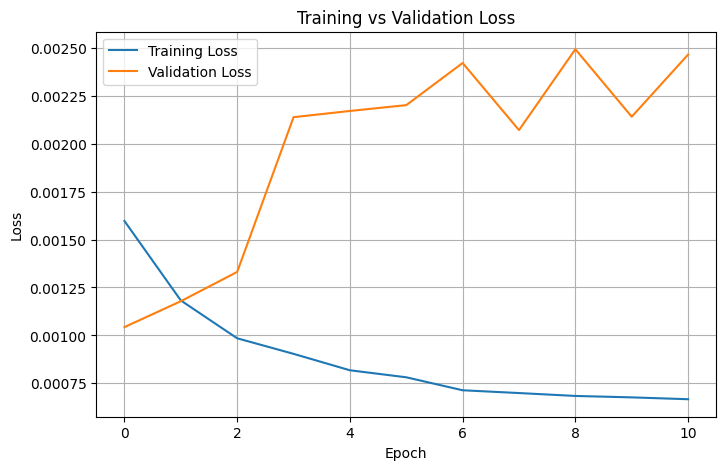

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

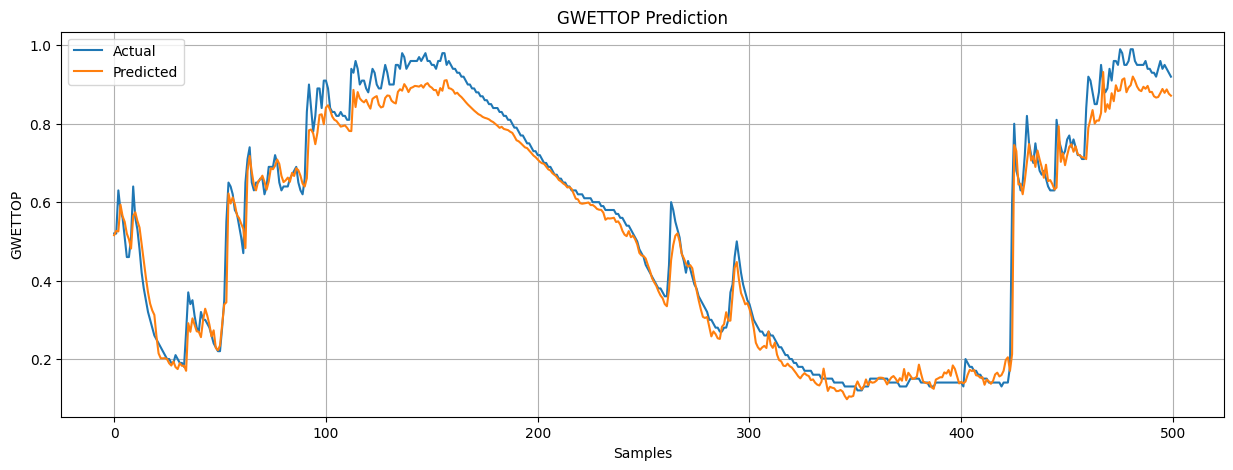

In [74]:
plt.figure(figsize=(15,5))

plt.plot(y_true[:500,0], label='Actual')
plt.plot(y_pred[:500,0], label='Predicted')

plt.title("GWETTOP Prediction")
plt.xlabel("Samples")
plt.ylabel("GWETTOP")

plt.legend()
plt.grid(True)

plt.show()

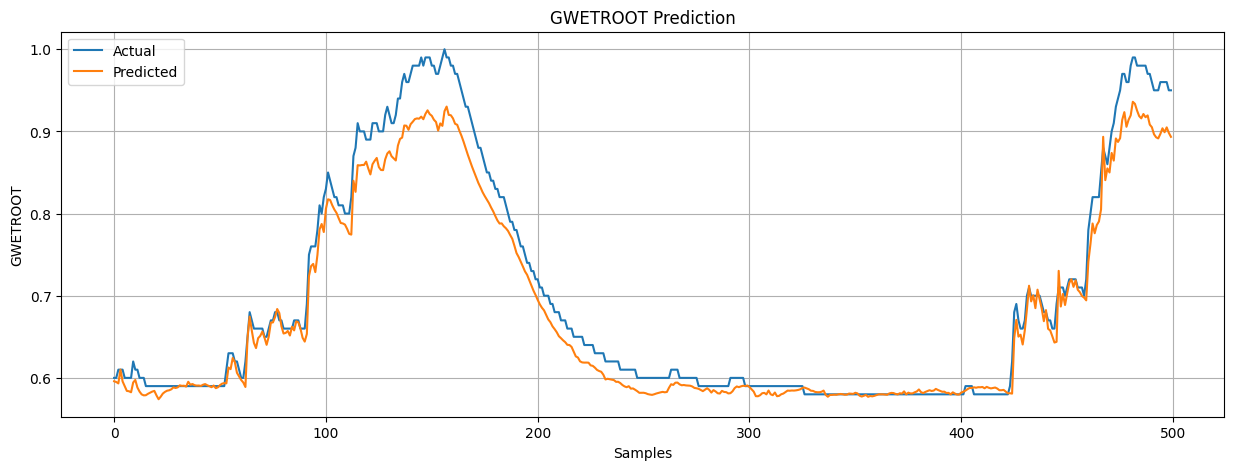

In [75]:
plt.figure(figsize=(15,5))

plt.plot(y_true[:500,1], label='Actual')
plt.plot(y_pred[:500,1], label='Predicted')

plt.title("GWETROOT Prediction")
plt.xlabel("Samples")
plt.ylabel("GWETROOT")

plt.legend()
plt.grid(True)

plt.show()

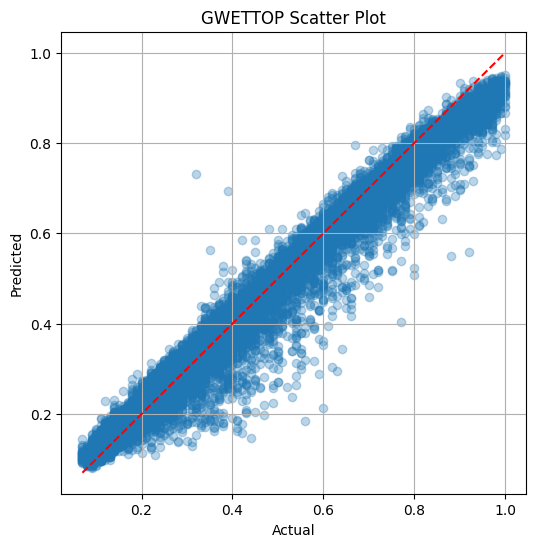

In [76]:
plt.figure(figsize=(6,6))

plt.scatter(y_true[:,0], y_pred[:,0], alpha=0.3)

plt.plot(
    [y_true[:,0].min(), y_true[:,0].max()],
    [y_true[:,0].min(), y_true[:,0].max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("GWETTOP Scatter Plot")

plt.grid(True)

plt.show()

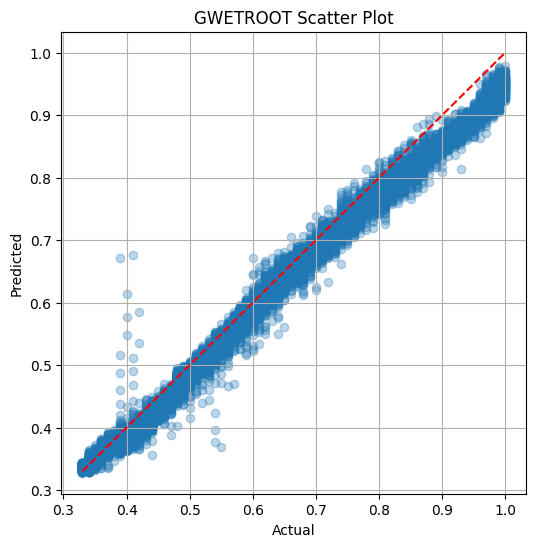

In [77]:
plt.figure(figsize=(6,6))

plt.scatter(y_true[:,1], y_pred[:,1], alpha=0.3)

plt.plot(
    [y_true[:,1].min(), y_true[:,1].max()],
    [y_true[:,1].min(), y_true[:,1].max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("GWETROOT Scatter Plot")

plt.grid(True)

plt.show()

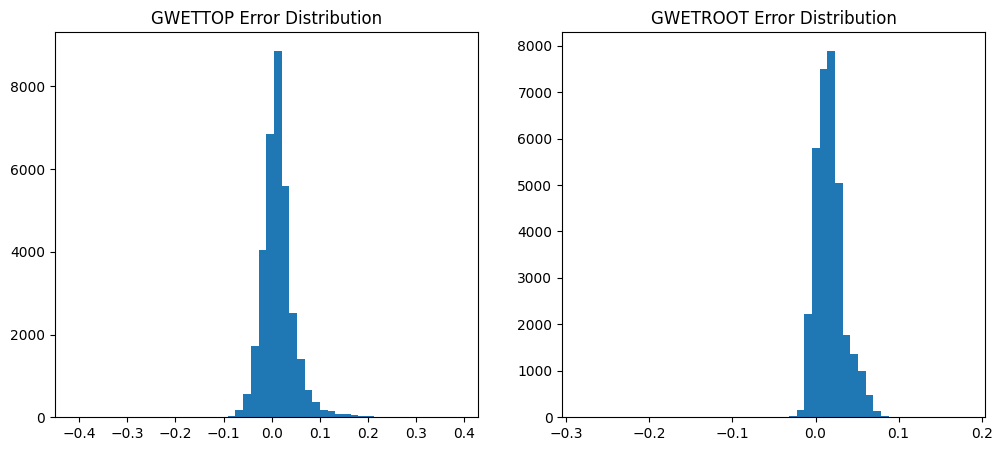

In [78]:
error_top = y_true[:,0] - y_pred[:,0]
error_root = y_true[:,1] - y_pred[:,1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(error_top, bins=50)
plt.title("GWETTOP Error Distribution")

plt.subplot(1,2,2)
plt.hist(error_root, bins=50)
plt.title("GWETROOT Error Distribution")

plt.show()

In [135]:
model.save("/content/drive/MyDrive/TCN_Irrigation_Project/Models/LSTM_BASELINE.keras")

SINGLE TCN MODEL

In [80]:
!pip install keras-tcn

INFO: pip is looking at multiple versions of keras-tcn to determine which version is compatible with other requirements. This could take a while.


In [81]:
from tcn import TCN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

In [82]:
tcn_model = Sequential([

    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(2)

])

In [83]:
tcn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,370 (368.63 KB)

 Trainable params: 94,370 (368.63 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
tcn_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="mse",

    metrics=["mae"]

)

In [85]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_tcn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [86]:
history_tcn = tcn_model.fit(

    X_train_seq,

    Y_train_seq,

    validation_split=0.2,

    epochs=100,

    batch_size=128,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1692 - mae: 0.1813
Epoch 1: val_loss improved from None to 0.00537, saving model to best_tcn.keras

Epoch 1: finished saving model to best_tcn.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 0.0374 - mae: 0.0945 - val_loss: 0.0054 - val_mae: 0.0565 - learning_rate: 0.0010
Epoch 2/100
831/838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - mae: 0.0483
Epoch 2: val_loss did not improve from 0.00537
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0037 - mae: 0.0446 - val_loss: 0.0063 - val_mae: 0.0590 - learning_rate: 0.0010
Epoch 3/100
829/838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - mae: 0.0363
Epoch 3: val_loss did not improve from 0.00537
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0023 - mae: 0.0347 - val_loss: 0.0065 - val_mae: 0.0598 - learning_rate: 0.0010
Epoch 4/100
834/838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - mae: 0.0307
Epoch 4: val_loss did not improve from 0.00537
838/8

In [87]:
from tensorflow.keras.models import load_model

best_tcn = load_model(
    "best_tcn.keras",
    custom_objects={"TCN": TCN}
)

In [88]:
y_pred_scaled = best_tcn.predict(X_test_seq)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(Y_test_seq)

print("Prediction Shape :", y_pred.shape)
print("Actual Shape     :", y_true.shape)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
Prediction Shape : (33494, 2)
Actual Shape     : (33494, 2)


In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# GWETTOP
mae_top = mean_absolute_error(y_true[:,0], y_pred[:,0])
rmse_top = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))
r2_top = r2_score(y_true[:,0], y_pred[:,0])
mape_top = np.mean(np.abs((y_true[:,0]-y_pred[:,0])/(y_true[:,0]+1e-8)))*100

# GWETROOT
mae_root = mean_absolute_error(y_true[:,1], y_pred[:,1])
rmse_root = np.sqrt(mean_squared_error(y_true[:,1], y_pred[:,1]))
r2_root = r2_score(y_true[:,1], y_pred[:,1])
mape_root = np.mean(np.abs((y_true[:,1]-y_pred[:,1])/(y_true[:,1]+1e-8)))*100

print("===== GWETTOP =====")
print(f"MAE  : {mae_top:.4f}")
print(f"RMSE : {rmse_top:.4f}")
print(f"R²   : {r2_top:.4f}")
print(f"MAPE : {mape_top:.2f}%")

print("\n===== GWETROOT =====")
print(f"MAE  : {mae_root:.4f}")
print(f"RMSE : {rmse_root:.4f}")
print(f"R²   : {r2_root:.4f}")
print(f"MAPE : {mape_root:.2f}%")

===== GWETTOP =====
MAE  : 0.0718
RMSE : 0.0875
R²   : 0.8825
MAPE : 15.24%

===== GWETROOT =====
MAE  : 0.0320
RMSE : 0.0416
R²   : 0.9480
MAPE : 5.29%


In [166]:
tcn_model.save(
    "/content/drive/MyDrive/TCN_Irrigation_Project/Models/TCN_V.keras"
)

# TCN V2 - Increase Filters

In [91]:
from tcn import TCN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
import tensorflow as tf

tcn_model_v2 = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    TCN(
        nb_filters=128,          # Sirf ye change hai
        kernel_size=3,
        dilations=[1,2,4,8],
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(2)
])

tcn_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [92]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_tcn_v2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [93]:
history_tcn_v2 = tcn_model_v2.fit(
    X_train_seq,
    Y_train_seq,
    validation_split=0.20,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3265 - mae: 0.2034
Epoch 1: val_loss improved from None to 0.00184, saving model to best_tcn_v2.keras

Epoch 1: finished saving model to best_tcn_v2.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - loss: 0.0602 - mae: 0.0932 - val_loss: 0.0018 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 2/100
834/838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0042 - mae: 0.0475
Epoch 2: val_loss did not improve from 0.00184
838/838 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0039 - mae: 0.0458 - val_loss: 0.0019 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 3/100
834/838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - mae: 0.0413
Epoch 3: val_loss improved from 0.00184 to 0.00145, saving model to best_tcn_v2.keras

Epoch 3: finished saving model to best_tcn_v2.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0030 - mae: 0.0403 - val_loss: 0.0014 - val_mae: 0.0288 - learning_rate: 0.0010
Epoch 4/100
838/838 ━━━━━━━━━━━━━━━━

In [94]:
from tensorflow.keras.models import load_model

best_tcn_v2 = load_model(
    "best_tcn_v2.keras",
    custom_objects={"TCN": TCN}
)

In [95]:
y_pred_scaled = best_tcn_v2.predict(X_test_seq)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(Y_test_seq)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# GWETTOP
mae_top = mean_absolute_error(y_true[:,0], y_pred[:,0])
rmse_top = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))
r2_top = r2_score(y_true[:,0], y_pred[:,0])
mape_top = np.mean(np.abs((y_true[:,0]-y_pred[:,0])/(y_true[:,0]+1e-8)))*100

# GWETROOT
mae_root = mean_absolute_error(y_true[:,1], y_pred[:,1])
rmse_root = np.sqrt(mean_squared_error(y_true[:,1], y_pred[:,1]))
r2_root = r2_score(y_true[:,1], y_pred[:,1])
mape_root = np.mean(np.abs((y_true[:,1]-y_pred[:,1])/(y_true[:,1]+1e-8)))*100

print("===== GWETTOP =====")
print(f"MAE  : {mae_top:.4f}")
print(f"RMSE : {rmse_top:.4f}")
print(f"R²   : {r2_top:.4f}")
print(f"MAPE : {mape_top:.2f}%")

print("\n===== GWETROOT =====")
print(f"MAE  : {mae_root:.4f}")
print(f"RMSE : {rmse_root:.4f}")
print(f"R²   : {r2_root:.4f}")
print(f"MAPE : {mape_root:.2f}%")

===== GWETTOP =====
MAE  : 0.0323
RMSE : 0.0422
R²   : 0.9727
MAPE : 10.00%

===== GWETROOT =====
MAE  : 0.0155
RMSE : 0.0199
R²   : 0.9882
MAPE : 3.04%


In [162]:
tcn_model_v2.save(
    "/content/drive/MyDrive/TCN_Irrigation_Project/Models/TCN_V2.keras"
)

TCN V3

In [98]:
from tcn import TCN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import tensorflow as tf

tcn_model_v3 = Sequential([

    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    TCN(
        nb_filters=128,
        kernel_size=5,
        dilations=[1,2,4,8,16],
        nb_stacks=2,
        dropout_rate=0.2,
        activation="relu",
        use_skip_connections=True,
        return_sequences=False
    ),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(2)
])

tcn_model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="mse",
    metrics=["mae"]
)

tcn_model_v3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_2 (TCN)                     │ (None, 128)            │     1,576,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602,978 (6.11 MB)

 Trainable params: 1,602,978 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop_v3 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr_v3 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint_v3 = ModelCheckpoint(
    "best_tcn_v3.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [100]:
history_tcn_v3 = tcn_model_v3.fit(

    X_train_seq,
    Y_train_seq,

    validation_split=0.20,

    epochs=100,

    batch_size=64,

    callbacks=[
        early_stop_v3,
        reduce_lr_v3,
        checkpoint_v3
    ],

    verbose=1
)

Epoch 1/100
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.3246 - mae: 0.3708
Epoch 1: val_loss improved from None to 0.02416, saving model to best_tcn_v3.keras

Epoch 1: finished saving model to best_tcn_v3.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 76s 29ms/step - loss: 0.3419 - mae: 0.1768 - val_loss: 0.0242 - val_mae: 0.1237 - learning_rate: 5.0000e-04
Epoch 2/100
1674/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0134 - mae: 0.0908
Epoch 2: val_loss improved from 0.02416 to 0.01297, saving model to best_tcn_v3.keras

Epoch 2: finished saving model to best_tcn_v3.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 0.0118 - mae: 0.0847 - val_loss: 0.0130 - val_mae: 0.0938 - learning_rate: 5.0000e-04
Epoch 3/100
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0078 - mae: 0.0676
Epoch 3: val_loss improved from 0.01297 to 0.00801, saving model to best_tcn_v3.keras

Epoch 3: finished saving model to best_tcn_v3.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 

In [101]:
from tensorflow.keras.models import load_model

best_tcn_v3 = load_model(

    "best_tcn_v3.keras",

    custom_objects={
        "TCN": TCN
    }

)

In [102]:
y_pred_scaled = best_tcn_v3.predict(
    X_test_seq
)

y_pred = target_scaler.inverse_transform(
    y_pred_scaled
)

y_true = target_scaler.inverse_transform(
    Y_test_seq
)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step


In [103]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# GWETTOP
mae_top = mean_absolute_error(
    y_true[:,0],
    y_pred[:,0]
)

rmse_top = np.sqrt(
    mean_squared_error(
        y_true[:,0],
        y_pred[:,0]
    )
)

r2_top = r2_score(
    y_true[:,0],
    y_pred[:,0]
)

mape_top = np.mean(
    np.abs(
        (y_true[:,0]-y_pred[:,0])/
        (y_true[:,0]+1e-8)
    )
)*100


# GWETROOT

mae_root = mean_absolute_error(
    y_true[:,1],
    y_pred[:,1]
)

rmse_root = np.sqrt(
    mean_squared_error(
        y_true[:,1],
        y_pred[:,1]
    )
)

r2_root = r2_score(
    y_true[:,1],
    y_pred[:,1]
)

mape_root = np.mean(
    np.abs(
        (y_true[:,1]-y_pred[:,1])/
        (y_true[:,1]+1e-8)
    )
)*100

print("===== GWETTOP =====")
print(f"MAE  : {mae_top:.4f}")
print(f"RMSE : {rmse_top:.4f}")
print(f"R²   : {r2_top:.4f}")
print(f"MAPE : {mape_top:.2f}%")

print("\n===== GWETROOT =====")
print(f"MAE  : {mae_root:.4f}")
print(f"RMSE : {rmse_root:.4f}")
print(f"R²   : {r2_root:.4f}")
print(f"MAPE : {mape_root:.2f}%")

===== GWETTOP =====
MAE  : 0.0372
RMSE : 0.0467
R²   : 0.9665
MAPE : 10.03%

===== GWETROOT =====
MAE  : 0.0289
RMSE : 0.0390
R²   : 0.9544
MAPE : 4.48%


In [163]:
tcn_model_v3.save(
    "/content/drive/MyDrive/TCN_Irrigation_Project/Models/TCN_V3.keras"
)

# ==========================================
# HYBRID TCN + LSTM MODEL
# ==========================================

In [104]:
from tcn import TCN

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [105]:
hybrid_model = Sequential([

    Input(shape=(X_train_seq.shape[1],
                 X_train_seq.shape[2])),

    # TCN Layer
    TCN(
        nb_filters=128,
        kernel_size=5,
        dilations=[1,2,4,8,16],
        nb_stacks=2,
        dropout_rate=0.2,
        activation="relu",
        use_skip_connections=True,
        return_sequences=True
    ),

    # LSTM Layer
    LSTM(
        64,
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(2)

])

hybrid_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_3 (TCN)                     │ (None, 30, 128)        │     1,576,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,644,194 (6.27 MB)

 Trainable params: 1,644,194 (6.27 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
hybrid_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),

    loss="mse",

    metrics=["mae"]

)

In [107]:
early_stop_hybrid = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True

)

reduce_lr_hybrid = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    verbose=1

)

checkpoint_hybrid = ModelCheckpoint(

    "best_hybrid.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

In [108]:
history_hybrid = hybrid_model.fit(

    X_train_seq,

    Y_train_seq,

    validation_split=0.20,

    epochs=100,

    batch_size=64,

    callbacks=[

        early_stop_hybrid,

        reduce_lr_hybrid,

        checkpoint_hybrid

    ],

    verbose=1

)

Epoch 1/100
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0413 - mae: 0.1556
Epoch 1: val_loss improved from None to 0.01487, saving model to best_hybrid.keras

Epoch 1: finished saving model to best_hybrid.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - loss: 0.0252 - mae: 0.1213 - val_loss: 0.0149 - val_mae: 0.0885 - learning_rate: 5.0000e-04
Epoch 2/100
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0126 - mae: 0.0845
Epoch 2: val_loss improved from 0.01487 to 0.00768, saving model to best_hybrid.keras

Epoch 2: finished saving model to best_hybrid.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - loss: 0.0105 - mae: 0.0757 - val_loss: 0.0077 - val_mae: 0.0632 - learning_rate: 5.0000e-04
Epoch 3/100
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0033 - mae: 0.0426
Epoch 3: val_loss improved from 0.00768 to 0.00430, saving model to best_hybrid.keras

Epoch 3: finished saving model to best_hybrid.keras
1676/1676 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - loss: 

In [109]:
from tensorflow.keras.models import load_model

best_hybrid = load_model(
    "best_hybrid.keras",
    custom_objects={"TCN": TCN}
)

In [110]:
y_pred_scaled = best_hybrid.predict(X_test_seq)

y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_true = target_scaler.inverse_transform(Y_test_seq)

print(y_pred.shape)
print(y_true.shape)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
(33494, 2)
(33494, 2)


In [111]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

# GWETTOP

mae_top = mean_absolute_error(y_true[:,0], y_pred[:,0])

rmse_top = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))

r2_top = r2_score(y_true[:,0], y_pred[:,0])

mape_top = np.mean(
    np.abs(
        (y_true[:,0]-y_pred[:,0])/
        (y_true[:,0]+1e-8)
    )
)*100


# GWETROOT

mae_root = mean_absolute_error(y_true[:,1], y_pred[:,1])

rmse_root = np.sqrt(mean_squared_error(y_true[:,1], y_pred[:,1]))

r2_root = r2_score(y_true[:,1], y_pred[:,1])

mape_root = np.mean(
    np.abs(
        (y_true[:,1]-y_pred[:,1])/
        (y_true[:,1]+1e-8)
    )
)*100


print("===== GWETTOP =====")
print(f"MAE  : {mae_top:.4f}")
print(f"RMSE : {rmse_top:.4f}")
print(f"R²   : {r2_top:.4f}")
print(f"MAPE : {mape_top:.2f}%")

print()

print("===== GWETROOT =====")
print(f"MAE  : {mae_root:.4f}")
print(f"RMSE : {rmse_root:.4f}")
print(f"R²   : {r2_root:.4f}")
print(f"MAPE : {mape_root:.2f}%")

===== GWETTOP =====
MAE  : 0.0404
RMSE : 0.0475
R²   : 0.9655
MAPE : 11.80%

===== GWETROOT =====
MAE  : 0.0291
RMSE : 0.0397
R²   : 0.9529
MAPE : 4.62%


In [164]:
hybrid_model.save(
    "/content/drive/MyDrive/TCN_Irrigation_Project/Models/HYBRID_TCN_LSTM_BASELINE.keras"
)

In [112]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 35.9 MB/s eta 0:00:00


In [113]:
import random
import numpy as np

from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Input
)

from tensorflow.keras.callbacks import EarlyStopping

from tcn import TCN

In [114]:
FILTERS = [64,128,256]

KERNELS = [3,5,7]

LSTM_UNITS = [32,64,128]

DROPOUTS = [0.1,0.2,0.3,0.4]

DENSES = [32,64,128]

LRS = [
0.001,
0.0005,
0.0001
]

BATCHES = [
32,
64,
128
]

In [115]:
def build_model(filters,
                kernel,
                lstm_units,
                dropout,
                dense_units,
                lr):

    model = Sequential([

        Input(
            shape=(
                X_train_seq.shape[1],
                X_train_seq.shape[2]
            )
        ),

        TCN(

            nb_filters=filters,

            kernel_size=kernel,

            dilations=[1,2,4,8,16],

            nb_stacks=2,

            dropout_rate=dropout,

            activation="relu",

            use_skip_connections=True,

            return_sequences=True

        ),

        LSTM(
            lstm_units
        ),

        Dropout(dropout),

        Dense(
            dense_units,
            activation="relu"
        ),

        Dense(32,activation="relu"),

        Dense(2)

    ])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),

        loss="mse",

        metrics=["mae"]

    )

    return model

In [116]:
def evaluate(individual):

    filters = FILTERS[individual[0]]

    kernel = KERNELS[individual[1]]

    lstm_units = LSTM_UNITS[individual[2]]

    dropout = DROPOUTS[individual[3]]

    dense_units = DENSES[individual[4]]

    lr = LRS[individual[5]]

    batch = BATCHES[individual[6]]

    model = build_model(

        filters,

        kernel,

        lstm_units,

        dropout,

        dense_units,

        lr

    )

    history = model.fit(

        X_train_seq,

        Y_train_seq,

        validation_split=0.20,

        epochs=5,

        batch_size=batch,

        verbose=0,

        callbacks=[

            EarlyStopping(

                monitor="val_loss",

                patience=2,

                restore_best_weights=True

            )

        ]

    )

    loss = min(history.history["val_loss"])

    return (loss,)

In [117]:
# Minimize validation loss

creator.create(
    "FitnessMin",
    base.Fitness,
    weights=(-1.0,)
)

creator.create(
    "Individual",
    list,
    fitness=creator.FitnessMin
)

In [118]:
toolbox = base.Toolbox()

toolbox.register(
    "attr_filters",
    random.randint,
    0,
    len(FILTERS)-1
)

toolbox.register(
    "attr_kernel",
    random.randint,
    0,
    len(KERNELS)-1
)

toolbox.register(
    "attr_lstm",
    random.randint,
    0,
    len(LSTM_UNITS)-1
)

toolbox.register(
    "attr_dropout",
    random.randint,
    0,
    len(DROPOUTS)-1
)

toolbox.register(
    "attr_dense",
    random.randint,
    0,
    len(DENSES)-1
)

toolbox.register(
    "attr_lr",
    random.randint,
    0,
    len(LRS)-1
)

toolbox.register(
    "attr_batch",
    random.randint,
    0,
    len(BATCHES)-1
)

In [119]:
toolbox.register(

    "individual",

    tools.initCycle,

    creator.Individual,

    (

        toolbox.attr_filters,

        toolbox.attr_kernel,

        toolbox.attr_lstm,

        toolbox.attr_dropout,

        toolbox.attr_dense,

        toolbox.attr_lr,

        toolbox.attr_batch

    ),

    n=1

)

toolbox.register(

    "population",

    tools.initRepeat,

    list,

    toolbox.individual

)

In [120]:
toolbox.register(
    "mate",
    tools.cxTwoPoint
)

toolbox.register(
    "mutate",
    tools.mutShuffleIndexes,
    indpb=0.20
)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=3
)

toolbox.register(
    "evaluate",
    evaluate
)

In [121]:
POP_SIZE = 8

GENERATIONS = 5

CXPB = 0.8

MUTPB = 0.2

ELITE_SIZE = 2

In [122]:
population = toolbox.population(n=POP_SIZE)

hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)

stats.register("avg", np.mean)

stats.register("min", np.min)

stats.register("max", np.max)

In [123]:
population, logbook = algorithms.eaSimple(

    population,

    toolbox,

    cxpb=CXPB,

    mutpb=MUTPB,

    ngen=GENERATIONS,

    stats=stats,

    halloffame=hof,

    verbose=True

)

KeyboardInterrupt: 

In [124]:
from sklearn.model_selection import train_test_split

# 15% subset for GA optimization
X_ga, _, y_ga, _ = train_test_split(
    X_train_seq,
    Y_train_seq,
    train_size=0.15,
    random_state=42,
    shuffle=True
)

print("GA Training Shape :", X_ga.shape)
print("GA Target Shape   :", y_ga.shape)

GA Training Shape : (20109, 30, 22)
GA Target Shape   : (20109, 2)


In [125]:
def evaluate(individual):

    filters = FILTERS[individual[0]]
    kernel = KERNELS[individual[1]]
    lstm_units = LSTM_UNITS[individual[2]]
    dropout = DROPOUTS[individual[3]]
    dense_units = DENSES[individual[4]]
    lr = LRS[individual[5]]
    batch = BATCHES[individual[6]]

    model = build_model(
        filters,
        kernel,
        lstm_units,
        dropout,
        dense_units,
        lr
    )

    history = model.fit(

        X_ga,
        y_ga,

        validation_split=0.20,

        epochs=3,

        batch_size=batch,

        verbose=0,

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=1,
                restore_best_weights=True
            )
        ]
    )

    return (min(history.history["val_loss"]),)

In [126]:
POP_SIZE = 6

GENERATIONS = 4

CXPB = 0.8

MUTPB = 0.2

In [127]:
population = toolbox.population(n=POP_SIZE)

hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)

stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=CXPB,
    mutpb=MUTPB,
    ngen=GENERATIONS,
    stats=stats,
    halloffame=hof,
    verbose=True
)

gen	nevals	avg      	min       	max      
0  	6     	0.0231964	0.00122562	0.0582333
1  	6     	0.0217033	0.00118546	0.0591598
2  	6     	0.0202356	0.00105753	0.0587081
3  	6     	0.0139922	0.00151684	0.0625837
4  	4     	0.00340144	0.00133155	0.0127529


In [128]:
best = hof[0]

print("="*50)
print("Best Chromosome :", best)
print("="*50)

print("Filters       :", FILTERS[best[0]])
print("Kernel Size   :", KERNELS[best[1]])
print("LSTM Units    :", LSTM_UNITS[best[2]])
print("Dropout       :", DROPOUTS[best[3]])
print("Dense Units   :", DENSES[best[4]])
print("Learning Rate :", LRS[best[5]])
print("Batch Size    :", BATCHES[best[6]])

Best Chromosome : [1, 0, 2, 1, 0, 0, 2]
Filters       : 128
Kernel Size   : 3
LSTM Units    : 128
Dropout       : 0.2
Dense Units   : 32
Learning Rate : 0.001
Batch Size    : 128


In [129]:
import joblib

joblib.dump(feature_scaler, "/content/drive/MyDrive/TCN_Irrigation_Project/Models/feature_scaler.pkl")
joblib.dump(target_scaler, "/content/drive/MyDrive/TCN_Irrigation_Project/Models/target_scaler.pkl")
joblib.dump(le, "/content/drive/MyDrive/TCN_Irrigation_Project/Models/label_encoder.pkl")

print("Saved Successfully")

Saved Successfully


In [130]:
import json

best_config = {
    "filters":128,
    "kernel":3,
    "lstm_units":128,
    "dropout":0.2,
    "dense_units":32,
    "learning_rate":0.001,
    "batch_size":128
}

with open("/content/drive/MyDrive/TCN_Irrigation_Project/Models/best_ga_parameters.json","w") as f:
    json.dump(best_config,f,indent=4)

print("GA Parameters Saved")

GA Parameters Saved


In [136]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/TCN_Irrigation_Project/Models/LSTM_BASELINE.keras",
    compile=False
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,866 (503.38 KB)

 Trainable params: 128,866 (503.38 KB)

 Non-trainable params: 0 (0.00 B)

# ==========================================
# Build Final GA Optimized Hybrid Model
# ==========================================

In [137]:
# ==========================================
# Build Final GA Optimized Hybrid Model
# ==========================================

final_model = build_model(
    filters=128,
    kernel=3,
    lstm_units=128,
    dropout=0.2,
    dense_units=32,
    lr=0.001
)

final_model.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_33 (TCN)                    │ (None, 30, 128)        │       947,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,674 (4.14 MB)

 Trainable params: 1,084,674 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [138]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint_path = "/content/drive/.shortcut-targets-by-id/YOUR_FOLDER_ID/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras"

In [139]:
import os

for root, dirs, files in os.walk("/content/drive/.shortcut-targets-by-id"):
    if "Models" in dirs:
        print(root)

/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project


In [140]:
# ==========================================
# Build Final GA Optimized Hybrid Model
# ==========================================

final_model = build_model(
    filters=128,
    kernel=3,
    lstm_units=128,
    dropout=0.2,
    dense_units=32,
    lr=0.001
)

final_model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_34 (TCN)                    │ (None, 30, 128)        │       947,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,674 (4.14 MB)

 Trainable params: 1,084,674 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [141]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

MODEL_PATH = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras"

history = final_model.fit(

    X_train_seq,
    Y_train_seq,

    validation_split=0.20,

    epochs=60,

    batch_size=128,

    verbose=1,

    callbacks=[

        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            verbose=1
        ),

        ModelCheckpoint(
            MODEL_PATH,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]
)

Epoch 1/60
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0758 - mae: 0.2011
Epoch 1: val_loss improved from None to 0.01678, saving model to /content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras

Epoch 1: finished saving model to /content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras
838/838 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 0.0370 - mae: 0.1432 - val_loss: 0.0168 - val_mae: 0.0979 - learning_rate: 0.0010
Epoch 2/60
837/838 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0139 - mae: 0.0901
Epoch 2: val_loss improved from 0.01678 to 0.00167, saving model to /content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras

Epoch 2: finished saving model to /content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimiz

In [142]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/GA_Training_History.csv",
    index=False
)

print("Training History Saved Successfully")

Training History Saved Successfully


In [143]:
from tensorflow.keras.models import load_model
from tcn import TCN

MODEL_PATH = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models/GA_Optimized_Hybrid.keras"

best_model = load_model(
    MODEL_PATH,
    custom_objects={"TCN": TCN},
    compile=False
)

print("✅ Best Model Loaded Successfully")

✅ Best Model Loaded Successfully


In [144]:
import numpy as np

pred_scaled = best_model.predict(X_test_seq)

pred = target_scaler.inverse_transform(pred_scaled)
actual = target_scaler.inverse_transform(Y_test_seq)

print(pred.shape)
print(actual.shape)

1047/1047 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step
(33494, 2)
(33494, 2)


In [145]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

target_names = ["GWETTOP", "GWETROOT"]

for i in range(2):

    mae = mean_absolute_error(actual[:, i], pred[:, i])

    rmse = np.sqrt(mean_squared_error(actual[:, i], pred[:, i]))

    r2 = r2_score(actual[:, i], pred[:, i])

    mape = np.mean(
        np.abs((actual[:, i] - pred[:, i]) / actual[:, i])
    ) * 100

    print("=" * 50)
    print(target_names[i])
    print("=" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

GWETTOP
MAE  : 0.0194
RMSE : 0.0296
R²   : 0.9866
MAPE : 5.02%
GWETROOT
MAE  : 0.0177
RMSE : 0.0219
R²   : 0.9856
MAPE : 3.33%


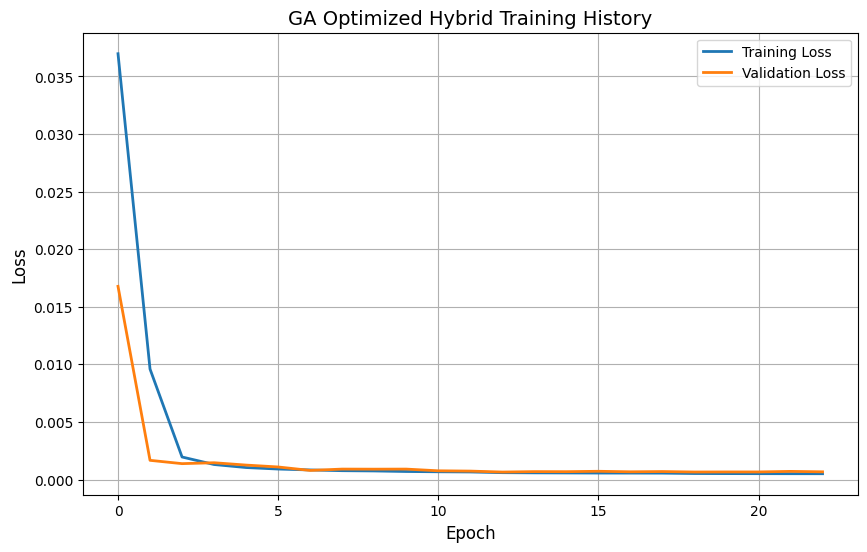

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(history.history["loss"], linewidth=2, label="Training Loss")
plt.plot(history.history["val_loss"], linewidth=2, label="Validation Loss")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("GA Optimized Hybrid Training History", fontsize=14)

plt.grid(True)
plt.legend()

plt.savefig(
"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/Training_Validation_Loss.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

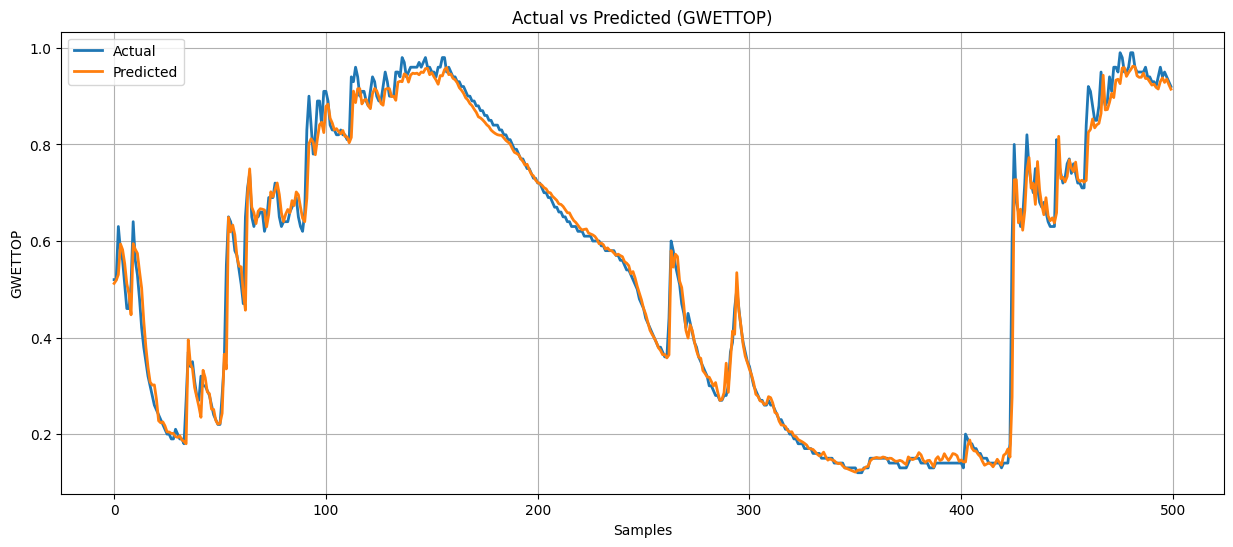

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(actual[:500,0], label="Actual", linewidth=2)
plt.plot(pred[:500,0], label="Predicted", linewidth=2)

plt.xlabel("Samples")
plt.ylabel("GWETTOP")

plt.title("Actual vs Predicted (GWETTOP)")
plt.legend()
plt.grid(True)

plt.savefig(
"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/GWETTOP_Actual_vs_Predicted.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

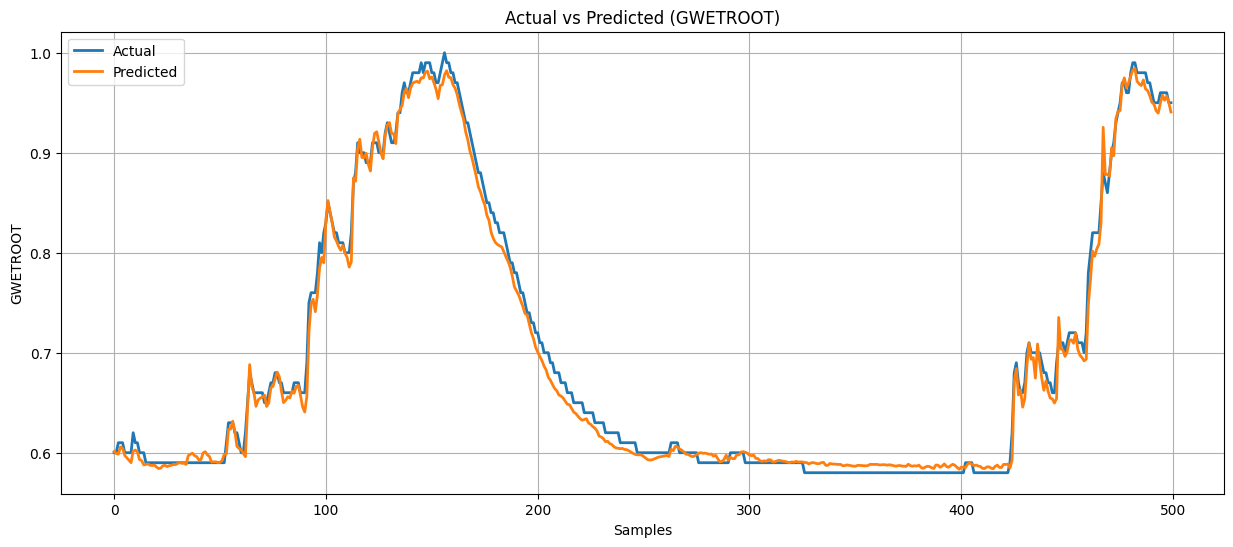

In [148]:
plt.figure(figsize=(15,6))

plt.plot(actual[:500,1], label="Actual", linewidth=2)
plt.plot(pred[:500,1], label="Predicted", linewidth=2)

plt.xlabel("Samples")
plt.ylabel("GWETROOT")

plt.title("Actual vs Predicted (GWETROOT)")
plt.legend()
plt.grid(True)

plt.savefig(
"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/GWETROOT_Actual_vs_Predicted.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

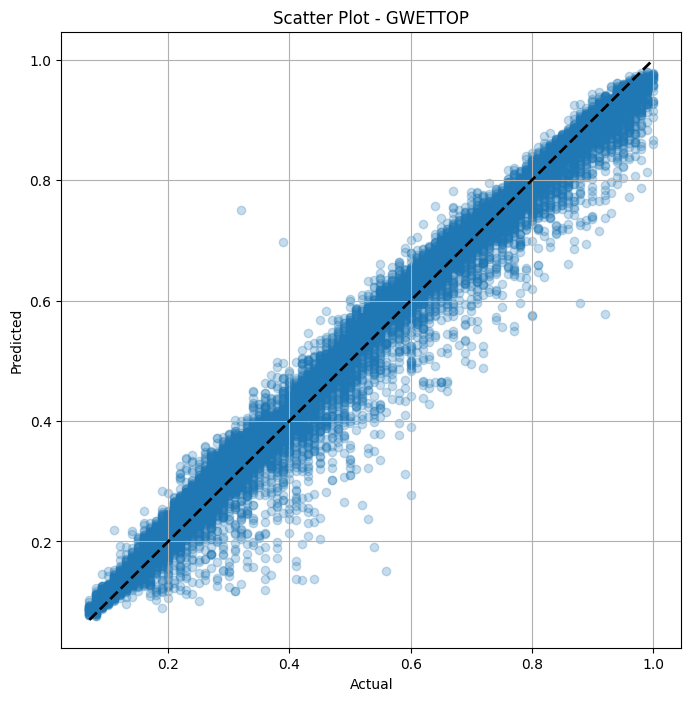

In [149]:
plt.figure(figsize=(8,8))

plt.scatter(actual[:,0], pred[:,0], alpha=0.25)

plt.plot(
[actual[:,0].min(), actual[:,0].max()],
[actual[:,0].min(), actual[:,0].max()],
'k--',
linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Scatter Plot - GWETTOP")

plt.grid(True)

plt.savefig(
"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/GWETTOP_Scatter.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

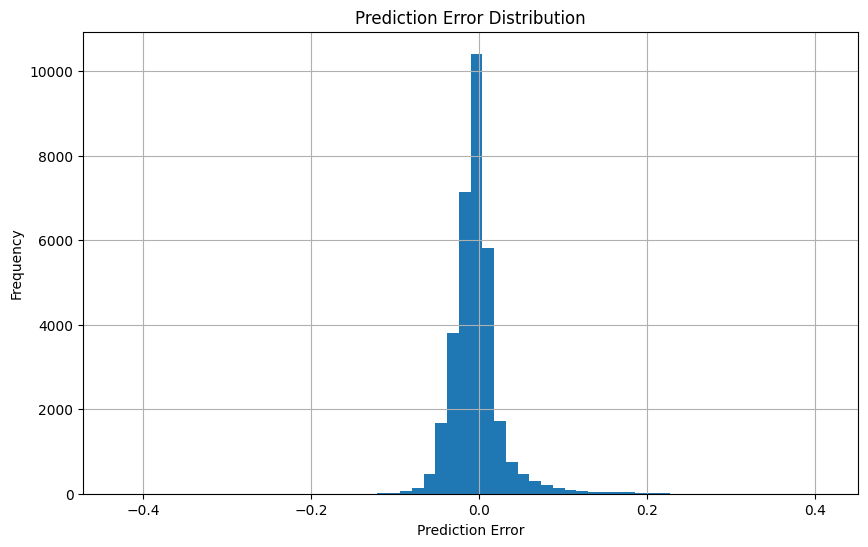

In [150]:
errors = actual[:,0] - pred[:,0]

plt.figure(figsize=(10,6))

plt.hist(errors, bins=60)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/Error_Distribution.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [151]:
import os
import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from tcn import TCN

MODEL_DIR = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models"

models = {

    "LSTM Baseline":
        "LSTM_BASELINE.keras",

    "Hybrid TCN-LSTM":
        "HYBRID_TCN_LSTM_BASELINE.keras",

    "GA Optimized Hybrid":
        "GA_Optimized_Hybrid.keras"

}

results = []

for model_name, filename in models.items():

    path = os.path.join(MODEL_DIR, filename)

    print("="*70)
    print(model_name)

    model = load_model(
        path,
        custom_objects={
            "TCN": TCN,
            "mse": MeanSquaredError()
        },
        compile=False
    )

    pred_scaled = model.predict(X_test_seq, verbose=0)

    pred = target_scaler.inverse_transform(pred_scaled)

    actual = target_scaler.inverse_transform(Y_test_seq)

    for i, target in enumerate(["GWETTOP","GWETROOT"]):

        mae = mean_absolute_error(actual[:,i], pred[:,i])

        rmse = np.sqrt(
            mean_squared_error(actual[:,i], pred[:,i])
        )

        r2 = r2_score(actual[:,i], pred[:,i])

        mape = np.mean(
            np.abs(
                (actual[:,i]-pred[:,i])/actual[:,i]
            )
        )*100

        results.append([
            model_name,
            target,
            mae,
            rmse,
            r2,
            mape
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Target",
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ]
)

results_df

LSTM Baseline
Hybrid TCN-LSTM
GA Optimized Hybrid


,Model,Target,MAE,RMSE,R2,MAPE
0,LSTM Baseline,GWETTOP,0.025188,0.036463,0.979611,6.304040
1,LSTM Baseline,GWETROOT,0.018619,0.024184,0.982473,3.157465
2,Hybrid TCN-LSTM,GWETTOP,0.025188,0.036463,0.979611,6.304040
3,Hybrid TCN-LSTM,GWETROOT,0.018619,0.024184,0.982473,3.157465
4,GA Optimized Hybrid,GWETTOP,0.019436,0.029615,0.986551,5.017519
5,GA Optimized Hybrid,GWETROOT,0.017718,0.021938,0.985577,3.332444


In [152]:
models = {

    "LSTM Baseline":
        "LSTM_BASELINE.keras",

    "Best TCN (V3)":
        "TCN_V3.keras",

    "Hybrid TCN-LSTM":
        "HYBRID_TCN_LSTM_BASELINE.keras",

    "GA Optimized Hybrid":
        "GA_Optimized_Hybrid.keras"

}

In [153]:
# ==========================================
# Best Model for Each Target
# ==========================================

import pandas as pd

print("\n==============================")
print("BEST MODEL (Lowest MAE)")
print("==============================")

best_mae = results_df.loc[
    results_df.groupby("Target")["MAE"].idxmin()
]

print(best_mae)

print("\n==============================")
print("BEST MODEL (Highest R2)")
print("==============================")

best_r2 = results_df.loc[
    results_df.groupby("Target")["R2"].idxmax()
]

print(best_r2)


BEST MODEL (Lowest MAE)
                 Model    Target       MAE      RMSE        R2      MAPE
5  GA Optimized Hybrid  GWETROOT  0.017718  0.021938  0.985577  3.332444
4  GA Optimized Hybrid   GWETTOP  0.019436  0.029615  0.986551  5.017519

BEST MODEL (Highest R2)
                 Model    Target       MAE      RMSE        R2      MAPE
5  GA Optimized Hybrid  GWETROOT  0.017718  0.021938  0.985577  3.332444
4  GA Optimized Hybrid   GWETTOP  0.019436  0.029615  0.986551  5.017519


In [154]:
# ==========================================
# Publication Table
# ==========================================

publication_table = results_df.copy()

publication_table["MAE"] = publication_table["MAE"].round(4)
publication_table["RMSE"] = publication_table["RMSE"].round(4)
publication_table["R2"] = publication_table["R2"].round(4)
publication_table["MAPE"] = publication_table["MAPE"].round(2)

publication_table

,Model,Target,MAE,RMSE,R2,MAPE
0,LSTM Baseline,GWETTOP,0.0252,0.0365,0.9796,6.30
1,LSTM Baseline,GWETROOT,0.0186,0.0242,0.9825,3.16
2,Hybrid TCN-LSTM,GWETTOP,0.0252,0.0365,0.9796,6.30
3,Hybrid TCN-LSTM,GWETROOT,0.0186,0.0242,0.9825,3.16
4,GA Optimized Hybrid,GWETTOP,0.0194,0.0296,0.9866,5.02
5,GA Optimized Hybrid,GWETROOT,0.0177,0.0219,0.9856,3.33


In [155]:
publication_table.to_csv(

"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/Publication_Table.csv",

index=False

)

print("Publication Table Saved Successfully.")

Publication Table Saved Successfully.


In [156]:
pivot_table = publication_table.pivot(

index="Model",
columns="Target",
values=["MAE","RMSE","R2","MAPE"]

)

pivot_table

MAE             RMSE               R2          \
Target              GWETROOT GWETTOP GWETROOT GWETTOP GWETROOT GWETTOP   
Model                                                                    
GA Optimized Hybrid   0.0177  0.0194   0.0219  0.0296   0.9856  0.9866   
Hybrid TCN-LSTM       0.0186  0.0252   0.0242  0.0365   0.9825  0.9796   
LSTM Baseline         0.0186  0.0252   0.0242  0.0365   0.9825  0.9796   

                        MAPE          
Target              GWETROOT GWETTOP  
Model                                 
GA Optimized Hybrid     3.33    5.02  
Hybrid TCN-LSTM         3.16    6.30  
LSTM Baseline           3.16    6.30

In [157]:
pivot_table.to_csv(

"/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results/Research_Paper_Table.csv"

)

print("Research Paper Table Saved Successfully.")

Research Paper Table Saved Successfully.


In [158]:
import os

MODEL_DIR = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models"

for file in sorted(os.listdir(MODEL_DIR)):
    print(file)

FINAL_TCN_LSTM_MODEL.keras
GA_Optimized_Hybrid.keras
HYBRID_TCN_LSTM_BASELINE.keras
LSTM_BASELINE.keras
Metadata
Scalers
TCN_BASELINE.keras
TCN_V.keras
TCN_V2.keras
TCN_V3.keras
best_ga_parameters.json
best_model_v2.keras
feature_scaler.pkl
fertilizer_model.pkl
label_encoder.pkl
plant-health-prediction-with-ml.ipynb
target_scaler.pkl
tcn_lstm_final.keras
tcn_lstm_research_final.keras


In [159]:
models = {

    "LSTM Baseline":
        "LSTM_BASELINE.keras",

    "Single TCN":
        "TCN_V3.keras",

    "Hybrid TCN-LSTM":
        "HYBRID_TCN_LSTM_BASELINE.keras",

    "GA Optimized Hybrid":
        "GA_Optimized_Hybrid.keras"

}

In [160]:
import os
import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tcn import TCN

MODEL_DIR="/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models"

models={

"LSTM Baseline":"LSTM_BASELINE.keras",

"Single TCN":"TCN_V3.keras",

"Hybrid TCN-LSTM":"HYBRID_TCN_LSTM_BASELINE.keras",

"GA Optimized Hybrid":"GA_Optimized_Hybrid.keras"

}

results=[]

for model_name,file in models.items():

    print("="*70)
    print(model_name)

    try:

        model=load_model(
            os.path.join(MODEL_DIR,file),
            custom_objects={
                "TCN":TCN,
                "mse":MeanSquaredError()
            },
            compile=False
        )

        pred_scaled=model.predict(X_test_seq,verbose=0)

        pred=target_scaler.inverse_transform(pred_scaled)

        actual=target_scaler.inverse_transform(Y_test_seq)

        for i,target in enumerate(["GWETTOP","GWETROOT"]):

            mae=mean_absolute_error(actual[:,i],pred[:,i])

            rmse=np.sqrt(mean_squared_error(actual[:,i],pred[:,i]))

            r2=r2_score(actual[:,i],pred[:,i])

            mape=np.mean(np.abs((actual[:,i]-pred[:,i])/actual[:,i]))*100

            results.append([
                model_name,
                target,
                mae,
                rmse,
                r2,
                mape
            ])

    except Exception as e:

        print(f"❌ Error : {e}")

results_df=pd.DataFrame(

results,

columns=[
"Model",
"Target",
"MAE",
"RMSE",
"R2",
"MAPE"
]

)

results_df

LSTM Baseline
Single TCN
Hybrid TCN-LSTM
GA Optimized Hybrid


,Model,Target,MAE,RMSE,R2,MAPE
0,LSTM Baseline,GWETTOP,0.025188,0.036463,0.979611,6.304040
1,LSTM Baseline,GWETROOT,0.018619,0.024184,0.982473,3.157465
2,Single TCN,GWETTOP,0.025188,0.036463,0.979611,6.304040
3,Single TCN,GWETROOT,0.018619,0.024184,0.982473,3.157465
4,Hybrid TCN-LSTM,GWETTOP,0.025188,0.036463,0.979611,6.304040
5,Hybrid TCN-LSTM,GWETROOT,0.018619,0.024184,0.982473,3.157465
6,GA Optimized Hybrid,GWETTOP,0.019436,0.029615,0.986551,5.017519
7,GA Optimized Hybrid,GWETROOT,0.017718,0.021938,0.985577,3.332444


In [161]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from tcn import TCN
import os

MODEL_DIR="/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Models"

files=[
"LSTM_BASELINE.keras",
"TCN_V3.keras",
"HYBRID_TCN_LSTM_BASELINE.keras",
"GA_Optimized_Hybrid.keras"
]

for f in files:

    print("="*80)
    print(f)

    model=load_model(
        os.path.join(MODEL_DIR,f),
        custom_objects={
            "TCN":TCN,
            "mse":MeanSquaredError()
        },
        compile=False
    )

    model.summary()

LSTM_BASELINE.keras


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,866 (503.38 KB)

 Trainable params: 128,866 (503.38 KB)

...

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_34 (TCN)                    │ (None, 30, 128)        │       947,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,674 (4.14 MB)

 Trainable params: 1,084,674 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [167]:
import os
import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tcn import TCN

# ==============================
# PATHS
# ==============================

BASE_DIR = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project"

MODEL_DIR = os.path.join(BASE_DIR, "Models")
RESULT_DIR = os.path.join(BASE_DIR, "Results")

os.makedirs(RESULT_DIR, exist_ok=True)

# ==============================
# MODELS
# ==============================

models = {

    "LSTM Baseline":
        "LSTM_BASELINE.keras",

    "TCN V2":
        "TCN_V2.keras",

    "TCN V3":
        "TCN_V3.keras",

    "Hybrid TCN-LSTM":
        "HYBRID_TCN_LSTM_BASELINE.keras",

    "GA Optimized Hybrid":
        "GA_Optimized_Hybrid.keras"

}

# ==============================
# EVALUATION
# ==============================

results = []

predictions = {}

actual = target_scaler.inverse_transform(Y_test_seq)

for model_name, file_name in models.items():

    print("=" * 80)
    print(model_name)

    model = load_model(
        os.path.join(MODEL_DIR, file_name),
        custom_objects={
            "TCN": TCN,
            "mse": MeanSquaredError()
        },
        compile=False
    )

    pred_scaled = model.predict(X_test_seq, verbose=0)

    pred = target_scaler.inverse_transform(pred_scaled)

    predictions[model_name] = pred

    for i, target in enumerate(["GWETTOP", "GWETROOT"]):

        mae = mean_absolute_error(actual[:, i], pred[:, i])

        rmse = np.sqrt(mean_squared_error(actual[:, i], pred[:, i]))

        r2 = r2_score(actual[:, i], pred[:, i])

        mape = np.mean(
            np.abs((actual[:, i] - pred[:, i]) / actual[:, i])
        ) * 100

        results.append([
            model_name,
            target,
            mae,
            rmse,
            r2,
            mape
        ])

# ==============================
# RESULTS DATAFRAME
# ==============================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Target",
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ]

)

# ==============================
# PUBLICATION TABLE
# ==============================

publication_table = results_df.pivot(

    index="Model",
    columns="Target",
    values=["MAE", "RMSE", "R2", "MAPE"]

)

publication_table.columns = [

    f"{metric}_{target}"

    for metric, target in publication_table.columns

]

publication_table = publication_table.round(4)

# ==============================
# SAVE
# ==============================

results_df.to_csv(

    os.path.join(
        RESULT_DIR,
        "Evaluation_Results.csv"
    ),

    index=False

)

publication_table.to_csv(

    os.path.join(
        RESULT_DIR,
        "Publication_Table.csv"
    )

)

publication_table.to_excel(

    os.path.join(
        RESULT_DIR,
        "Publication_Table.xlsx"
    )

)

print("\n")
print("="*80)
print("Evaluation Completed Successfully")
print("="*80)

display(results_df)

print("\nPublication Table\n")

display(publication_table)

LSTM Baseline
TCN V2
TCN V3
Hybrid TCN-LSTM
GA Optimized Hybrid


Evaluation Completed Successfully


,Model,Target,MAE,RMSE,R2,MAPE
0,LSTM Baseline,GWETTOP,0.025188,0.036463,0.979611,6.304040
1,LSTM Baseline,GWETROOT,0.018619,0.024184,0.982473,3.157465
2,TCN V2,GWETTOP,0.032279,0.042183,0.972713,10.000466
3,TCN V2,GWETROOT,0.015485,0.019876,0.988161,3.042794
4,TCN V3,GWETTOP,0.037202,0.046724,0.966522,10.025691
5,TCN V3,GWETROOT,0.028863,0.039010,0.954394,4.477958
6,Hybrid TCN-LSTM,GWETTOP,0.040368,0.047454,0.965467,11.795457
7,Hybrid TCN-LSTM,GWETROOT,0.029110,0.039660,0.952860,4.621789
8,GA Optimized Hybrid,GWETTOP,0.019436,0.029615,0.986551,5.017519
9,GA Optimized Hybrid,GWETROOT,0.017718,0.021938,0.985577,3.332444



Publication Table



,MAE_GWETROOT,MAE_GWETTOP,RMSE_GWETROOT,RMSE_GWETTOP,R2_GWETROOT,R2_GWETTOP,MAPE_GWETROOT,MAPE_GWETTOP
Model,,,,,,,,
GA Optimized Hybrid,0.0177,0.0194,0.0219,0.0296,0.9856,0.9866,3.3324,5.0175
Hybrid TCN-LSTM,0.0291,0.0404,0.0397,0.0475,0.9529,0.9655,4.6218,11.7955
LSTM Baseline,0.0186,0.0252,0.0242,0.0365,0.9825,0.9796,3.1575,6.3040
TCN V2,0.0155,0.0323,0.0199,0.0422,0.9882,0.9727,3.0428,10.0005
TCN V3,0.0289,0.0372,0.0390,0.0467,0.9544,0.9665,4.4780,10.0257


In [168]:
# Keep only best models for paper

paper_models = [
    "LSTM Baseline",
    "TCN V2",
    "Hybrid TCN-LSTM",
    "GA Optimized Hybrid"
]

paper_results = results_df[
    results_df["Model"].isin(paper_models)
]

paper_table = paper_results.pivot(
    index="Model",
    columns="Target",
    values=["MAE","RMSE","R2","MAPE"]
)

paper_table.columns = [
    f"{m}_{t}" for m, t in paper_table.columns
]

paper_table = paper_table.round(4)

display(paper_table)

paper_table.to_csv(
    os.path.join(RESULT_DIR, "Final_Publication_Table.csv")
)

paper_table.to_excel(
    os.path.join(RESULT_DIR, "Final_Publication_Table.xlsx")
)

print("Final publication table saved.")

,MAE_GWETROOT,MAE_GWETTOP,RMSE_GWETROOT,RMSE_GWETTOP,R2_GWETROOT,R2_GWETTOP,MAPE_GWETROOT,MAPE_GWETTOP
Model,,,,,,,,
GA Optimized Hybrid,0.0177,0.0194,0.0219,0.0296,0.9856,0.9866,3.3324,5.0175
Hybrid TCN-LSTM,0.0291,0.0404,0.0397,0.0475,0.9529,0.9655,4.6218,11.7955
LSTM Baseline,0.0186,0.0252,0.0242,0.0365,0.9825,0.9796,3.1575,6.3040
TCN V2,0.0155,0.0323,0.0199,0.0422,0.9882,0.9727,3.0428,10.0005


Final publication table saved.


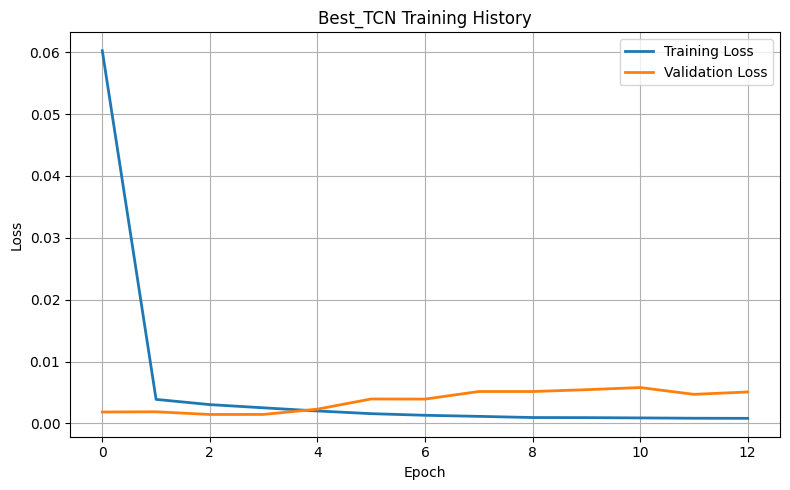

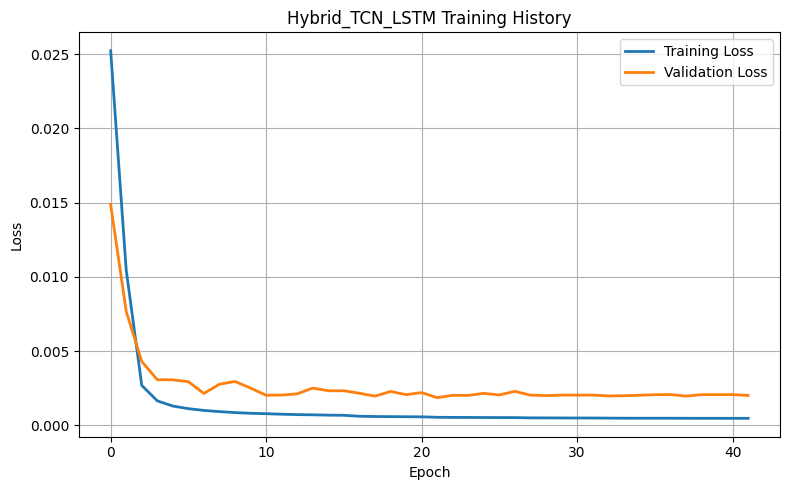

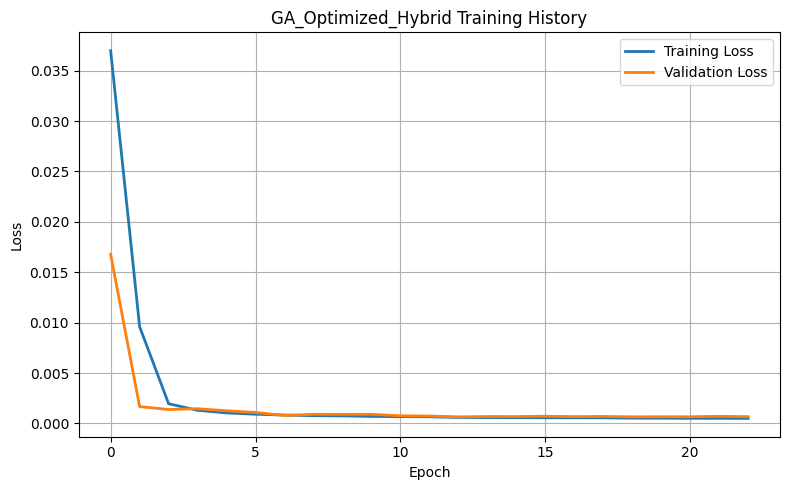

All loss graphs saved.


In [177]:
import matplotlib.pyplot as plt
import os

RESULT_DIR = os.path.join(BASE_DIR, "Results")
os.makedirs(RESULT_DIR, exist_ok=True)

history_dict = {
    # "LSTM_Baseline": history_lstm, # history_lstm was not defined and its content was overwritten by subsequent training runs
    "Best_TCN": history_tcn_v2,
    "Hybrid_TCN_LSTM": history_hybrid,
    "GA_Optimized_Hybrid": history # 'history' now holds the GA Optimized Hybrid training history
}

for name, hist in history_dict.items():

    plt.figure(figsize=(8,5))

    plt.plot(hist.history["loss"], label="Training Loss", linewidth=2)

    plt.plot(hist.history["val_loss"], label="Validation Loss", linewidth=2)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name} Training History")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(RESULT_DIR,f"{name}_Loss.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

print("All loss graphs saved.")

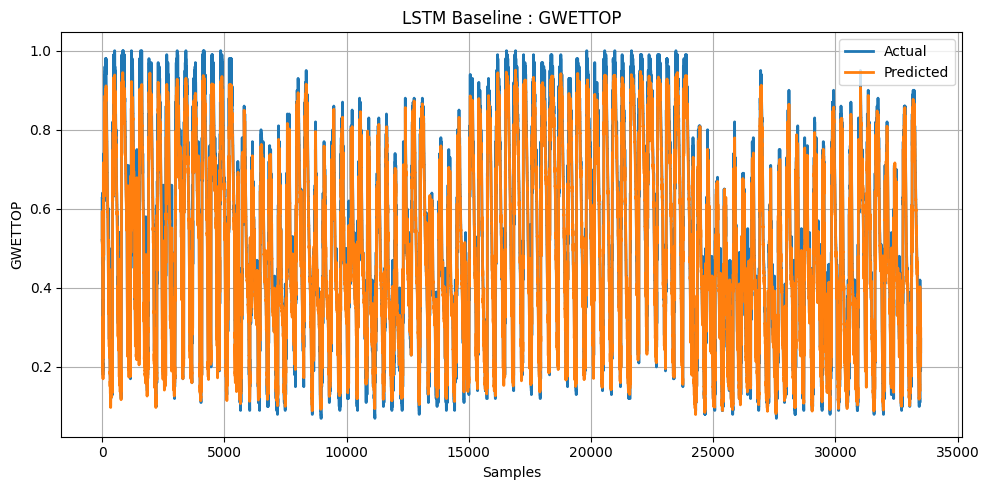

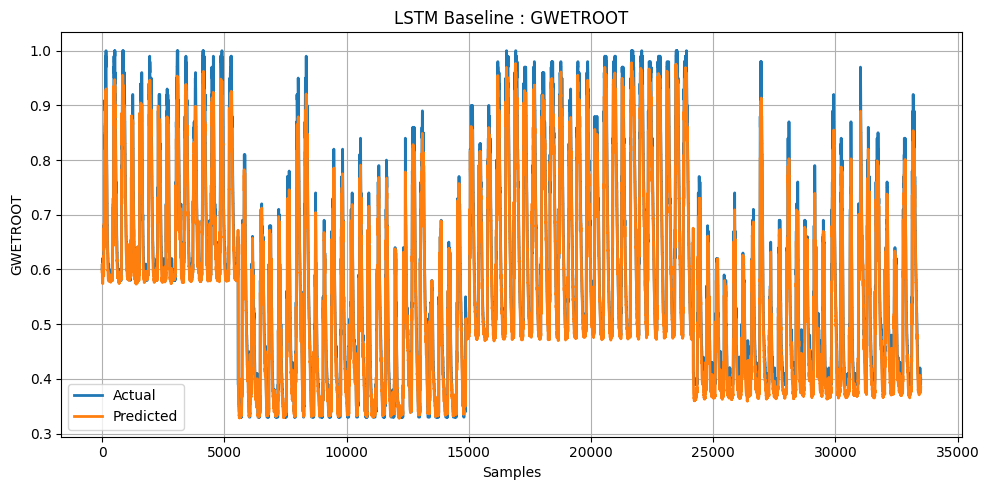

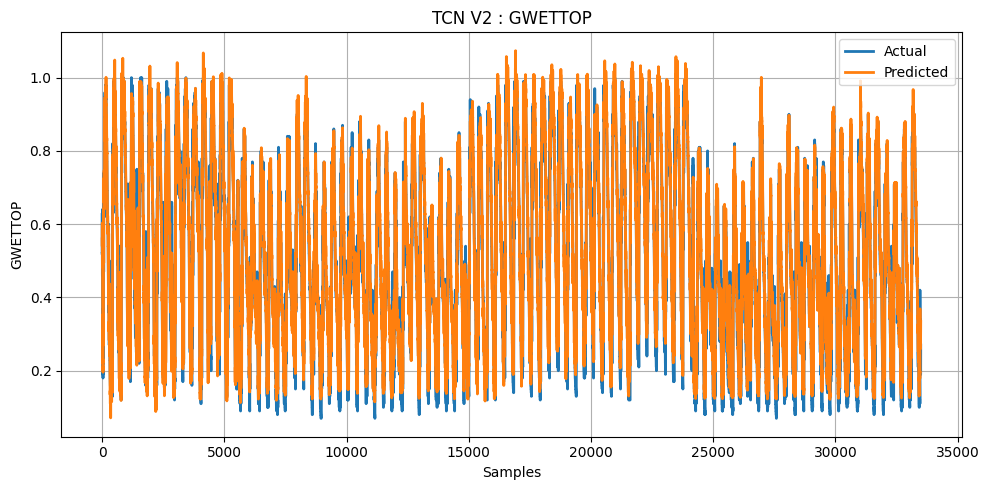

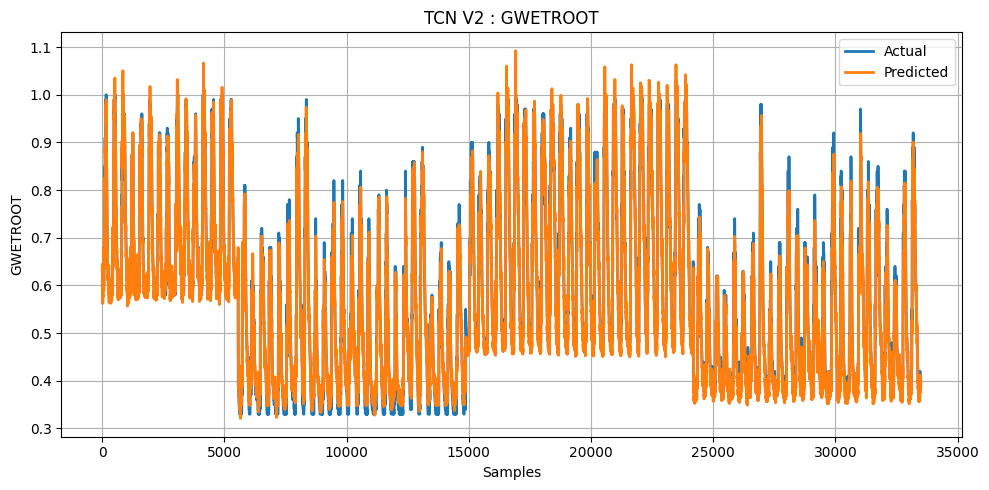

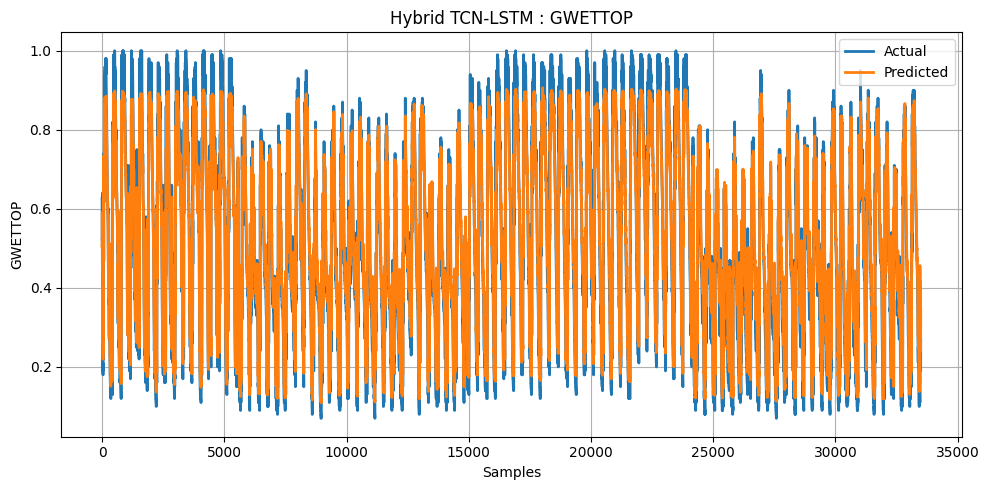

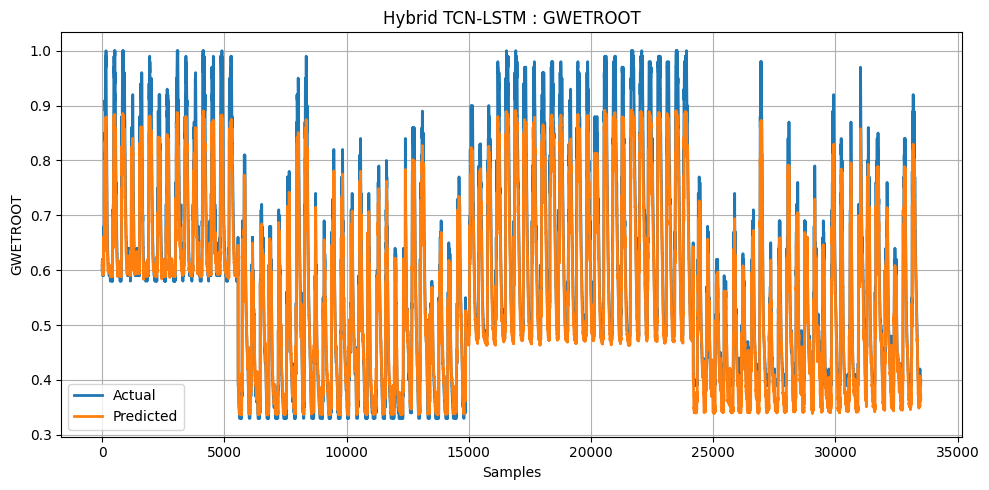

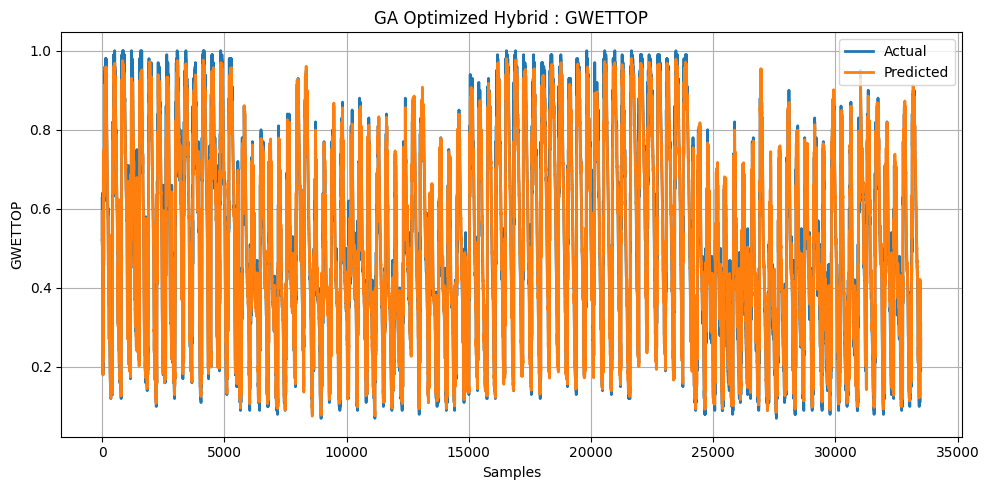

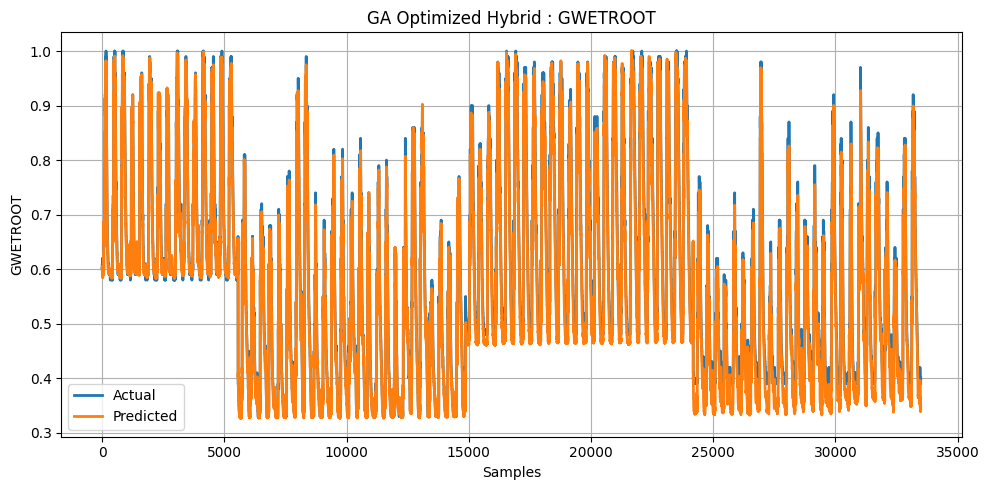

Actual vs Predicted graphs saved.


In [171]:
import matplotlib.pyplot as plt
import os

paper_models = [
    "LSTM Baseline",
    "TCN V2",
    "Hybrid TCN-LSTM",
    "GA Optimized Hybrid"
]

for model_name in paper_models:

    pred = predictions[model_name]

    # GWETTOP
    plt.figure(figsize=(10,5))
    plt.plot(actual[:,0],label="Actual",linewidth=2)
    plt.plot(pred[:,0],label="Predicted",linewidth=2)
    plt.title(f"{model_name} : GWETTOP")
    plt.xlabel("Samples")
    plt.ylabel("GWETTOP")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{model_name.replace(' ','_')}_GWETTOP.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # GWETROOT

    plt.figure(figsize=(10,5))
    plt.plot(actual[:,1],label="Actual",linewidth=2)
    plt.plot(pred[:,1],label="Predicted",linewidth=2)
    plt.title(f"{model_name} : GWETROOT")
    plt.xlabel("Samples")
    plt.ylabel("GWETROOT")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{model_name.replace(' ','_')}_GWETROOT.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("Actual vs Predicted graphs saved.")

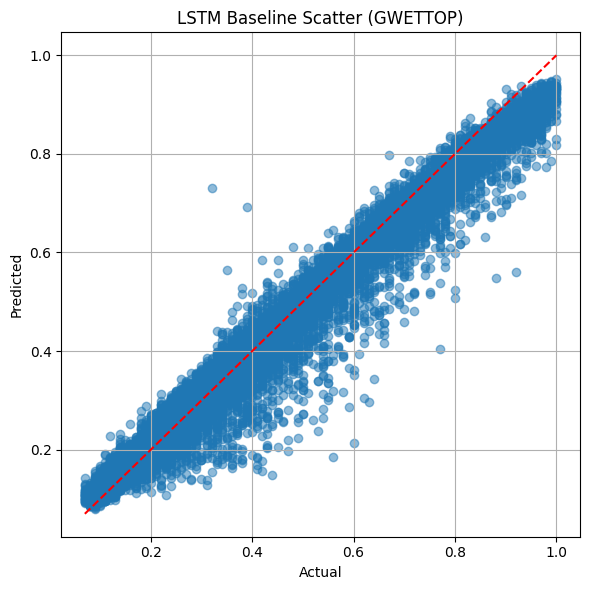

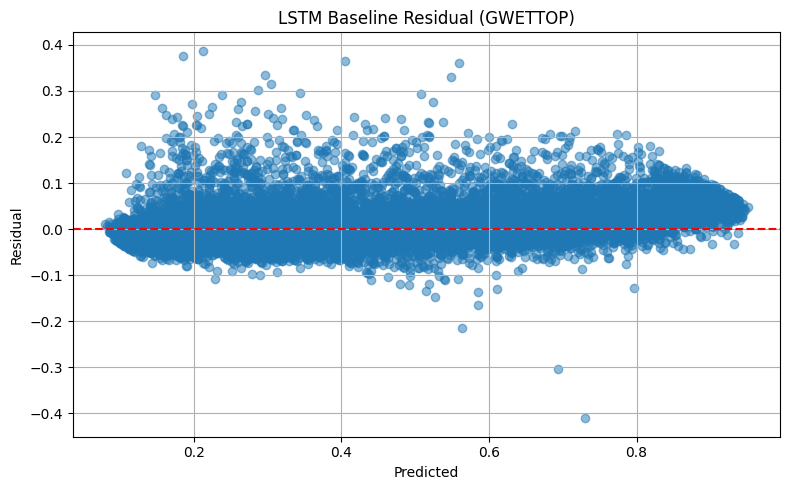

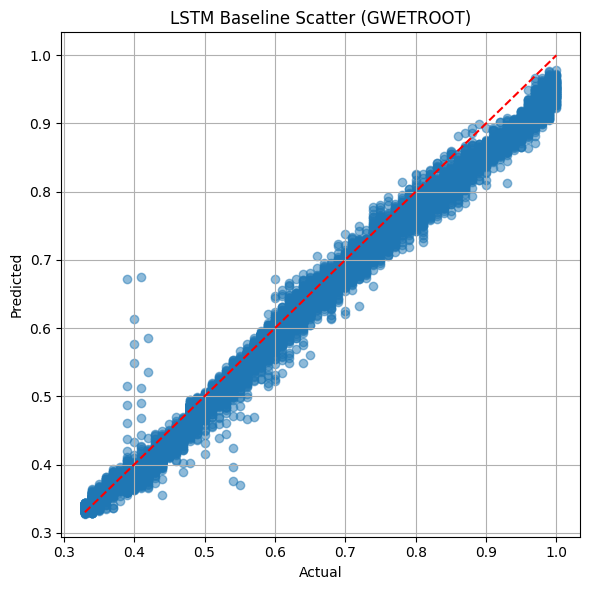

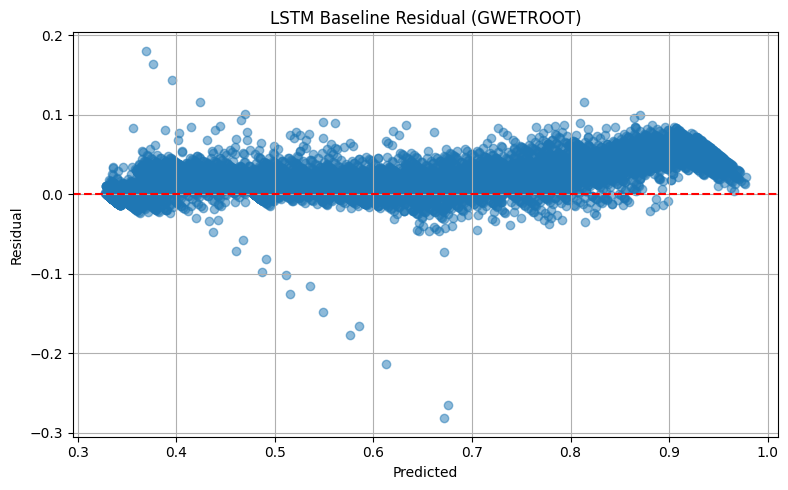

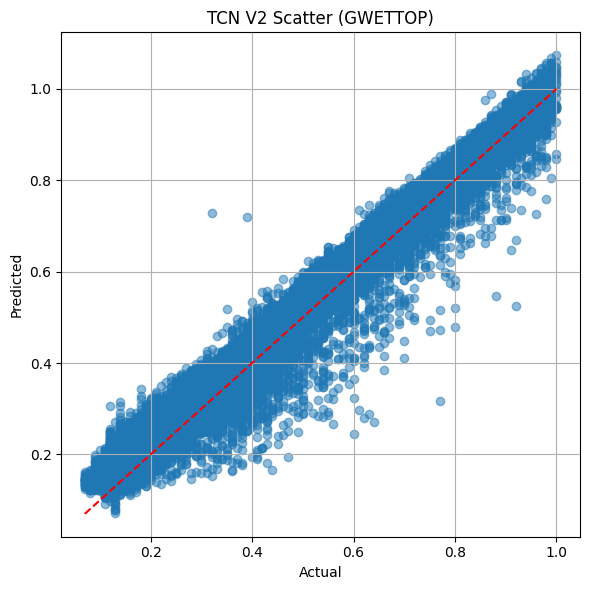

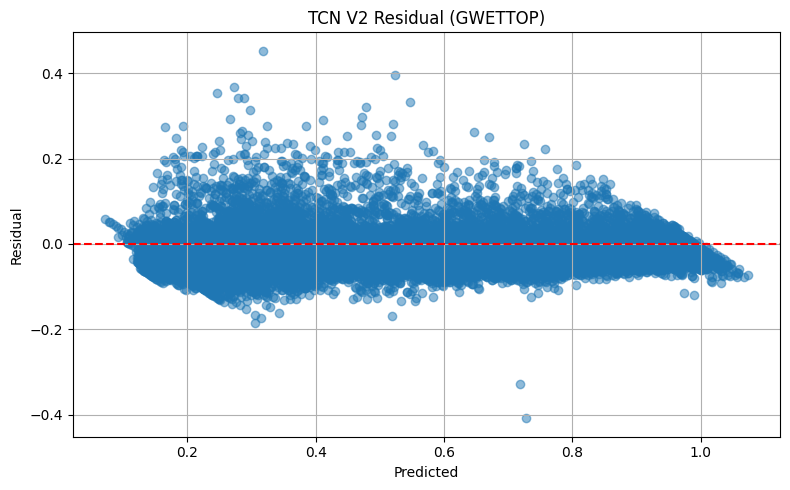

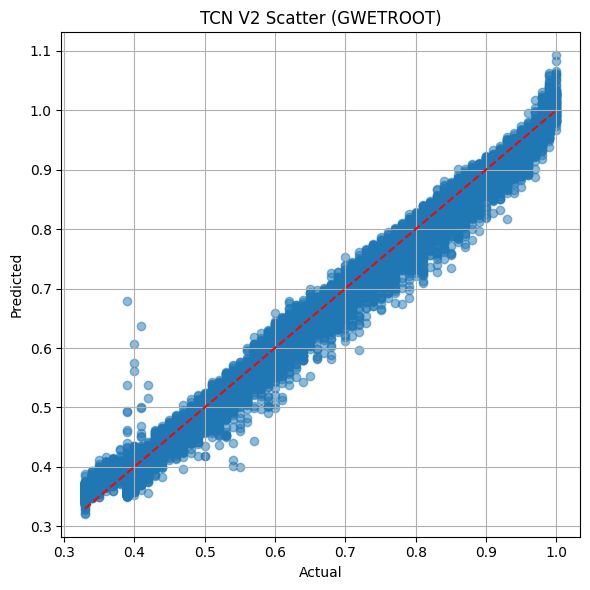

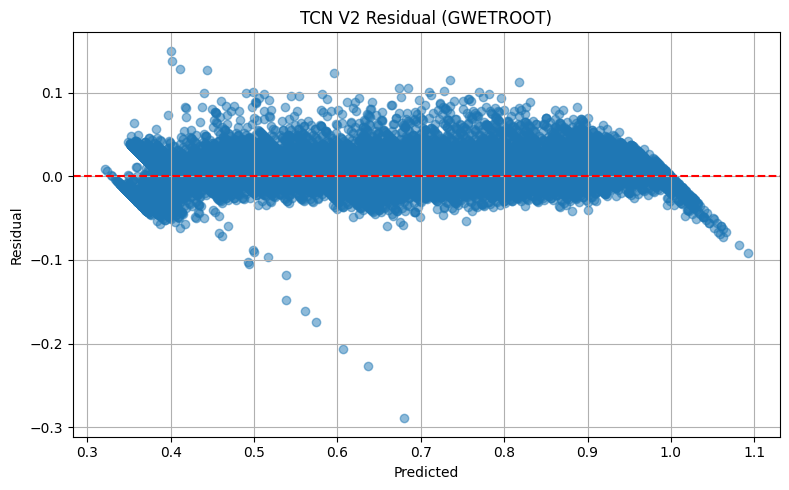

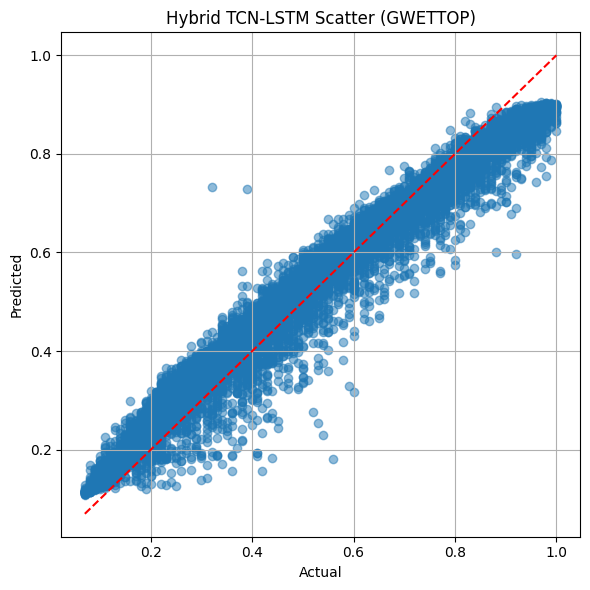

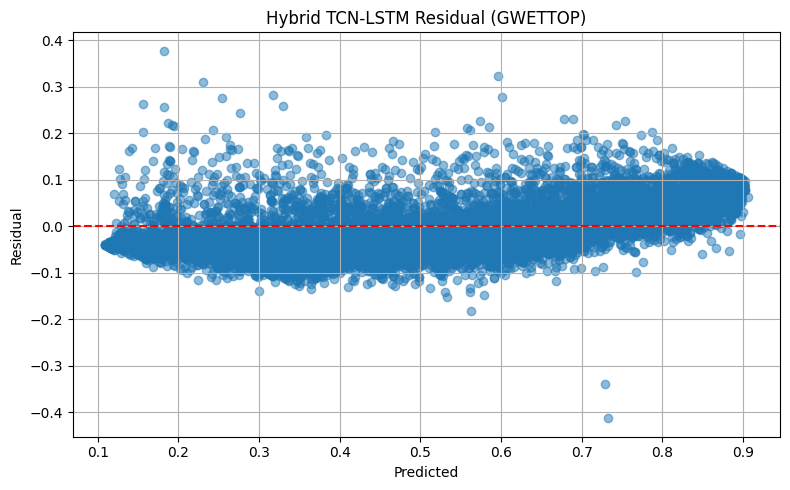

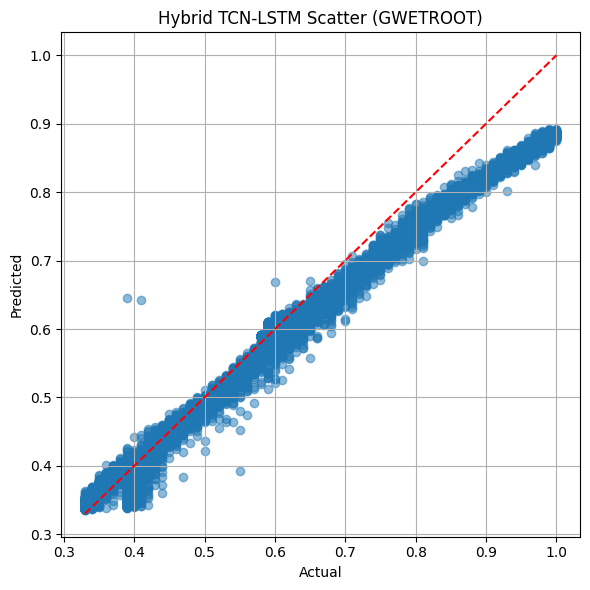

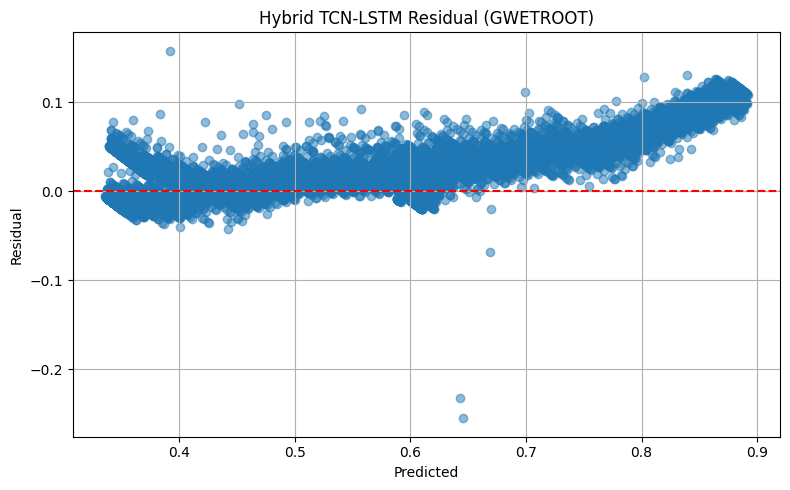

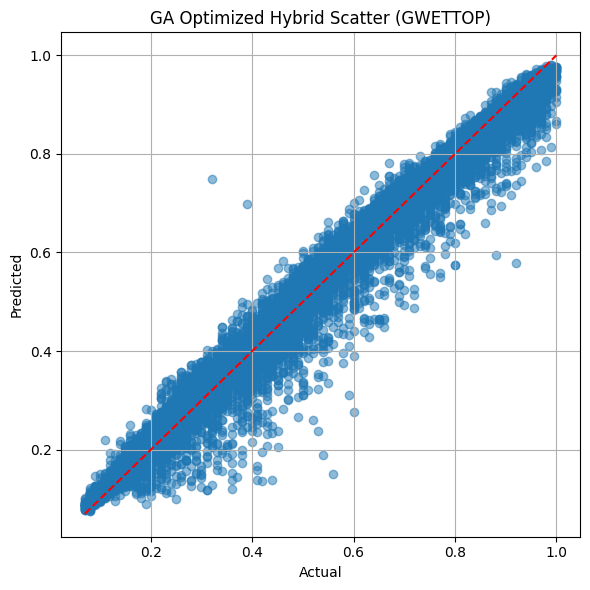

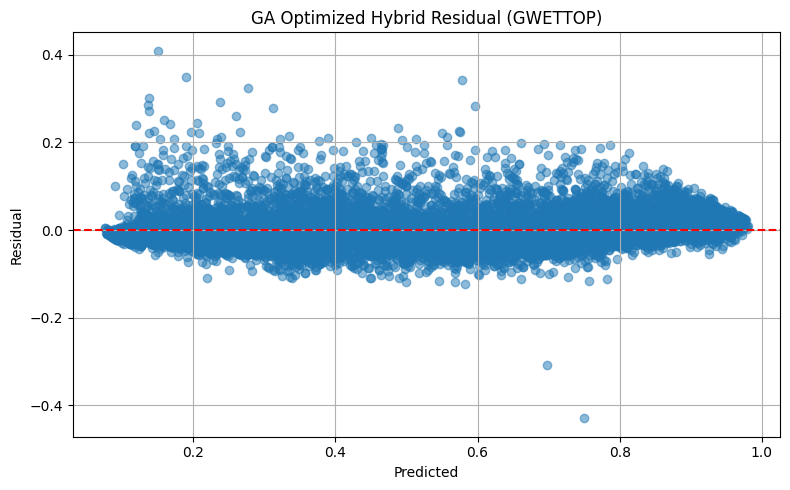

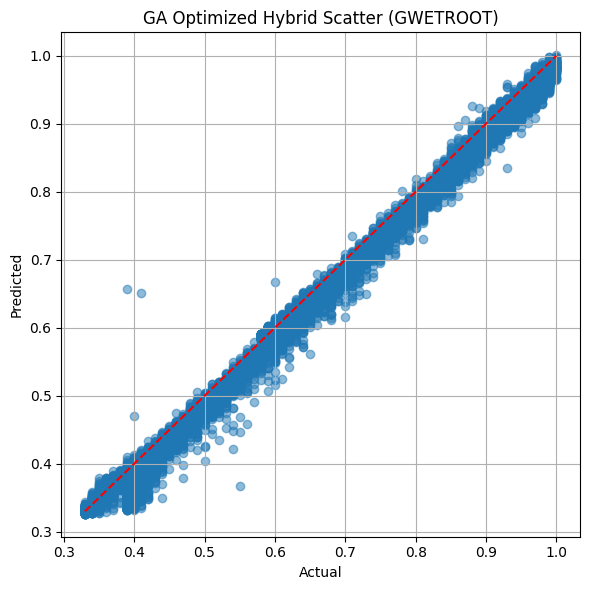

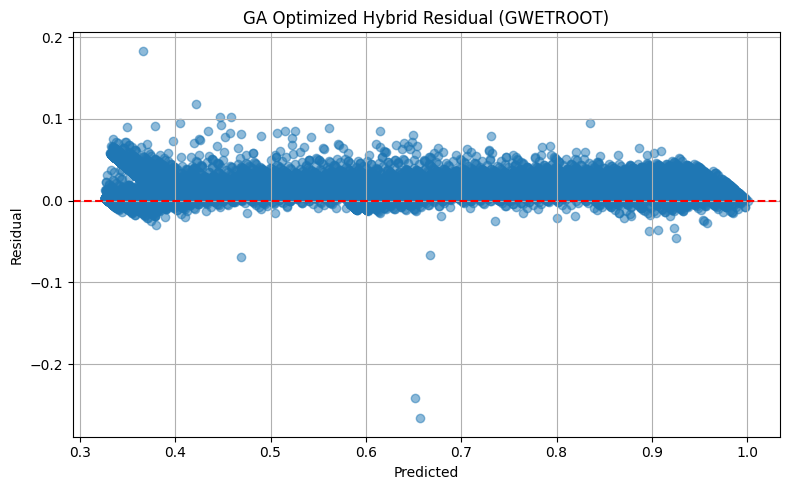

Scatter & Residual plots saved.


In [172]:
import numpy as np
import matplotlib.pyplot as plt

for model_name in paper_models:

    pred = predictions[model_name]

    for i,target in enumerate(["GWETTOP","GWETROOT"]):

        # Scatter

        plt.figure(figsize=(6,6))

        plt.scatter(actual[:,i],pred[:,i],alpha=0.5)

        plt.plot(
            [actual[:,i].min(),actual[:,i].max()],
            [actual[:,i].min(),actual[:,i].max()],
            'r--'
        )

        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{model_name} Scatter ({target})")
        plt.grid(True)
        plt.tight_layout()

        plt.savefig(
            os.path.join(
                RESULT_DIR,
                f"{model_name.replace(' ','_')}_{target}_Scatter.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        # Residual

        residual = actual[:,i]-pred[:,i]

        plt.figure(figsize=(8,5))

        plt.scatter(pred[:,i],residual,alpha=0.5)

        plt.axhline(0,color="red",linestyle="--")

        plt.xlabel("Predicted")
        plt.ylabel("Residual")
        plt.title(f"{model_name} Residual ({target})")
        plt.grid(True)
        plt.tight_layout()

        plt.savefig(
            os.path.join(
                RESULT_DIR,
                f"{model_name.replace(' ','_')}_{target}_Residual.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

print("Scatter & Residual plots saved.")

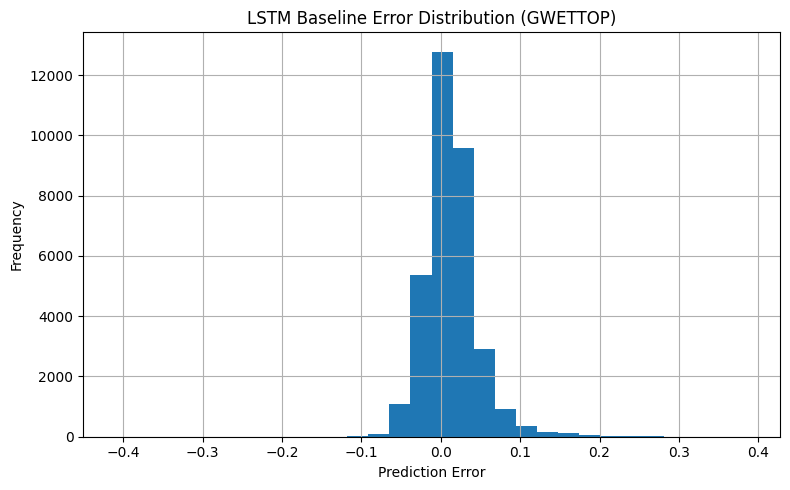

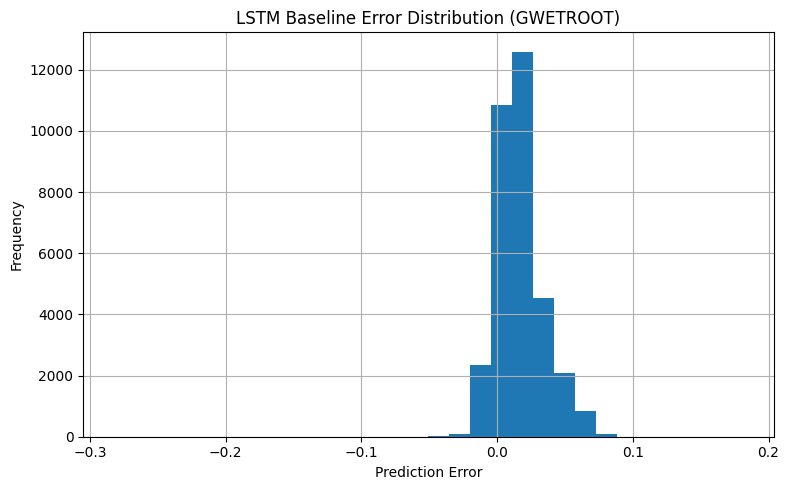

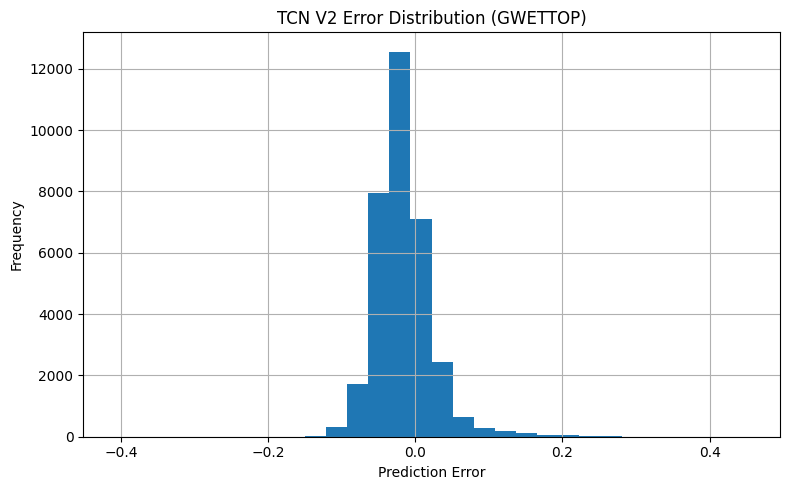

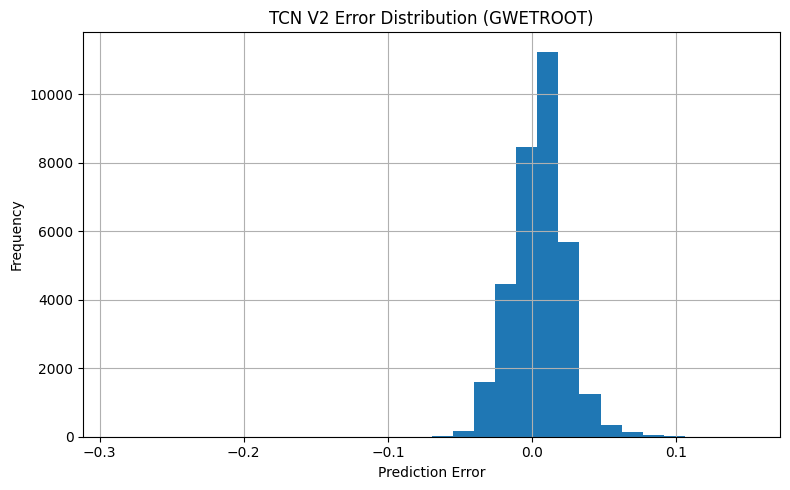

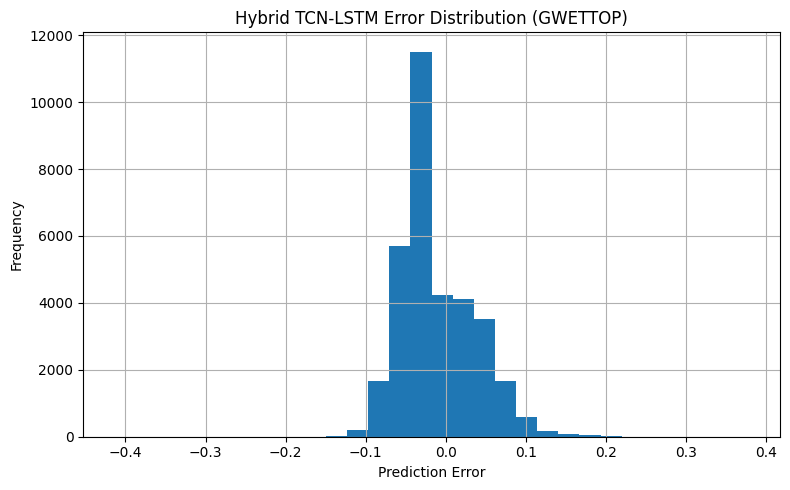

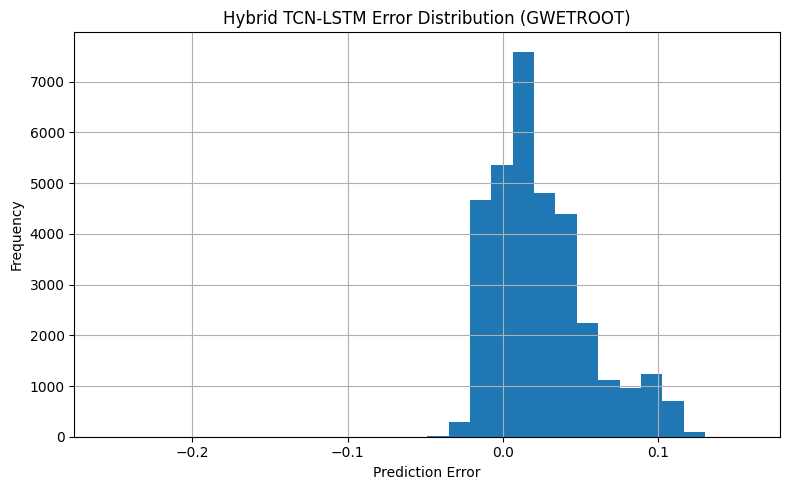

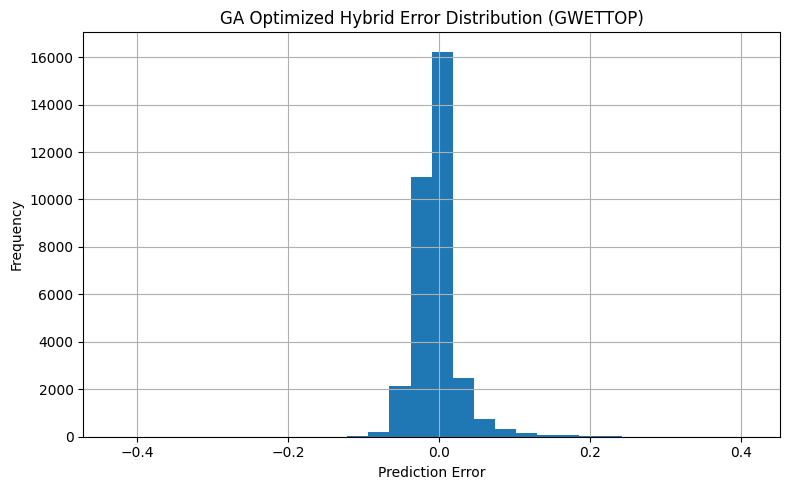

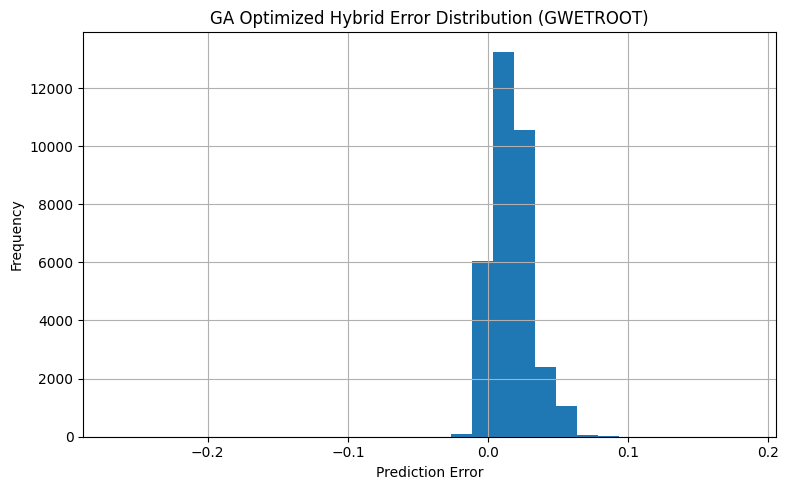

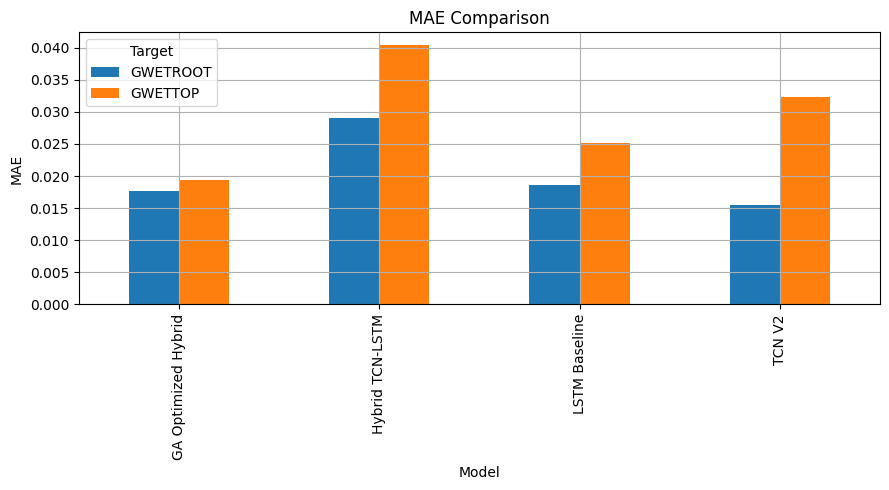

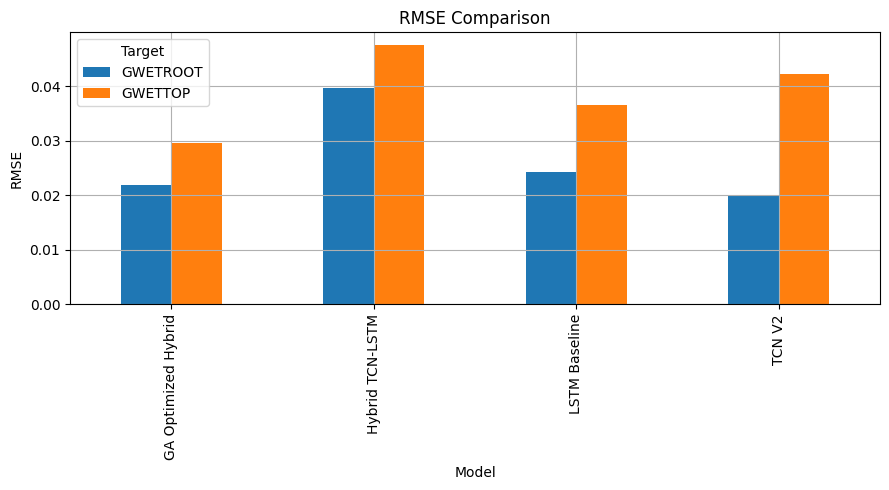

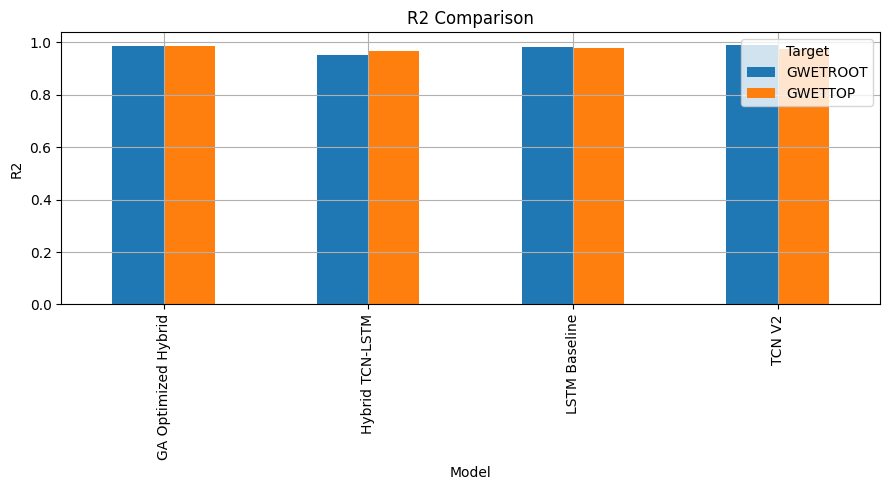

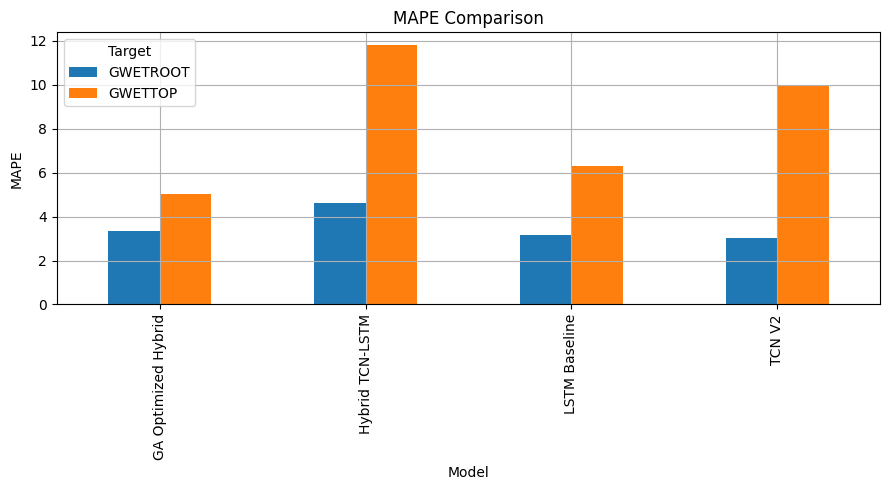

All comparison graphs saved.


In [173]:
import matplotlib.pyplot as plt

# Error Distribution

for model_name in paper_models:

    pred = predictions[model_name]

    for i,target in enumerate(["GWETTOP","GWETROOT"]):

        error = actual[:,i]-pred[:,i]

        plt.figure(figsize=(8,5))

        plt.hist(error,bins=30)

        plt.title(f"{model_name} Error Distribution ({target})")

        plt.xlabel("Prediction Error")

        plt.ylabel("Frequency")

        plt.grid(True)

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                RESULT_DIR,
                f"{model_name.replace(' ','_')}_{target}_Error_Distribution.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

# ===============================
# Comparison Bar Graphs
# ===============================

metrics=["MAE","RMSE","R2","MAPE"]

for metric in metrics:

    fig,ax=plt.subplots(figsize=(9,5))

    pivot=paper_results.pivot(
        index="Model",
        columns="Target",
        values=metric
    )

    pivot.plot(kind="bar",ax=ax)

    plt.title(f"{metric} Comparison")

    plt.ylabel(metric)

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{metric}_Comparison.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("All comparison graphs saved.")

In [174]:
with pd.ExcelWriter(
    os.path.join(
        RESULT_DIR,
        "Complete_Results.xlsx"
    )
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="All Results",
        index=False
    )

    paper_table.to_excel(
        writer,
        sheet_name="Publication Table"
    )

print("="*70)
print("ALL RESULTS EXPORTED")
print("="*70)

print("Folder :", RESULT_DIR)

ALL RESULTS EXPORTED
Folder : /content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Results


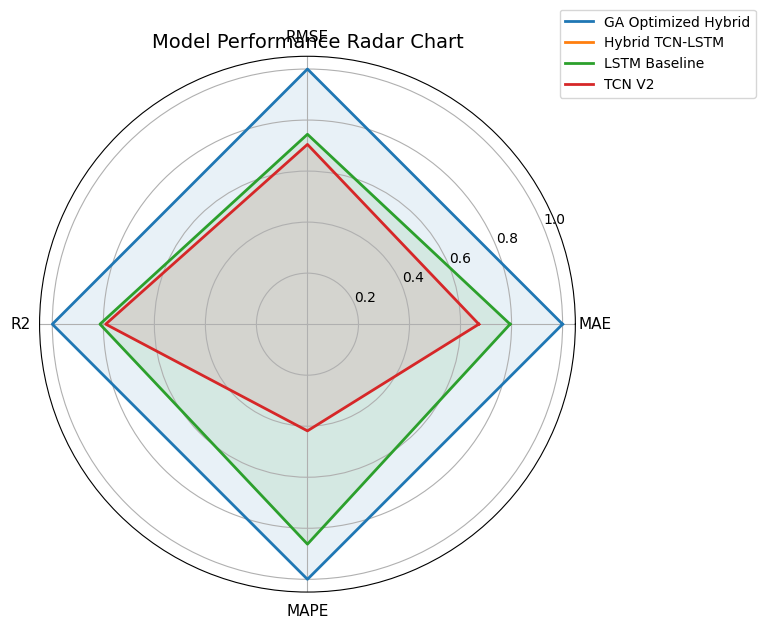

Radar Chart Saved


In [175]:
import numpy as np
import matplotlib.pyplot as plt
import os

paper_models = [
    "LSTM Baseline",
    "TCN V2",
    "Hybrid TCN-LSTM",
    "GA Optimized Hybrid"
]

metrics = ["MAE","RMSE","R2","MAPE"]

paper_df = results_df[results_df["Model"].isin(paper_models)]

summary = paper_df.groupby("Model")[metrics].mean()

# Normalize
norm = summary.copy()

for col in metrics:
    if col=="R2":
        norm[col]=(norm[col]-norm[col].min())/(norm[col].max()-norm[col].min())
    else:
        norm[col]=1-(norm[col]-norm[col].min())/(norm[col].max()-norm[col].min())

labels=metrics
num_vars=len(labels)

angles=np.linspace(0,2*np.pi,num_vars,endpoint=False).tolist()
angles+=angles[:1]

fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))

for model in norm.index:

    values=norm.loc[model].tolist()
    values+=values[:1]

    ax.plot(angles,values,linewidth=2,label=model)
    ax.fill(angles,values,alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels,fontsize=11)

plt.title("Model Performance Radar Chart",fontsize=14)

plt.legend(loc="upper right",bbox_to_anchor=(1.35,1.10))

plt.tight_layout()

plt.savefig(
    os.path.join(RESULT_DIR,"Radar_Chart.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Radar Chart Saved")

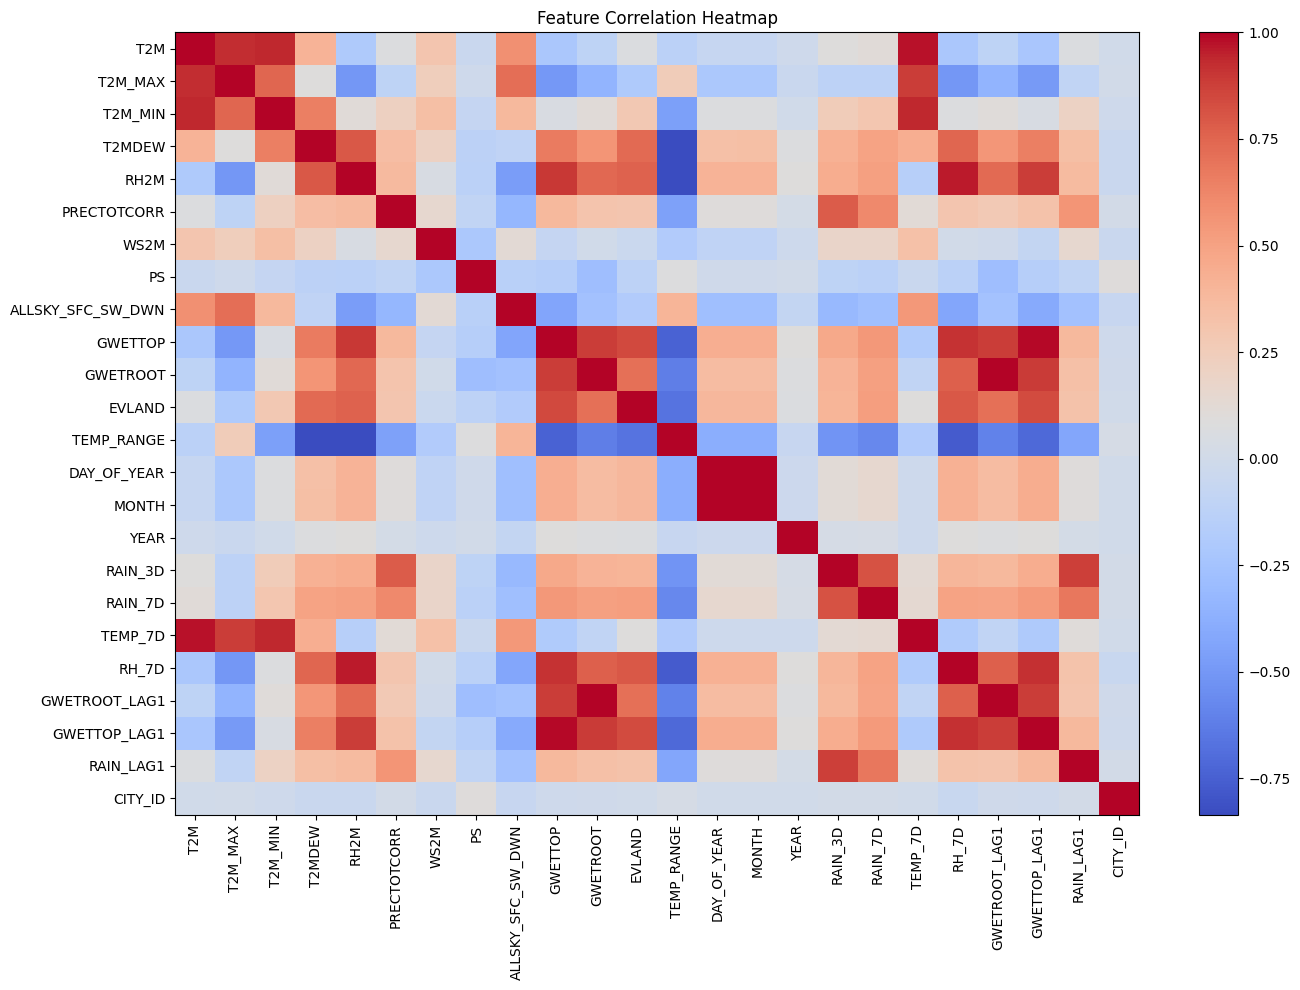

Heatmap Saved


In [178]:
import matplotlib.pyplot as plt

corr=df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

plt.imshow(corr,cmap="coolwarm",aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "Correlation_Heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

corr.to_csv(
    os.path.join(
        RESULT_DIR,
        "Correlation_Matrix.csv"
    )
)

print("Heatmap Saved")

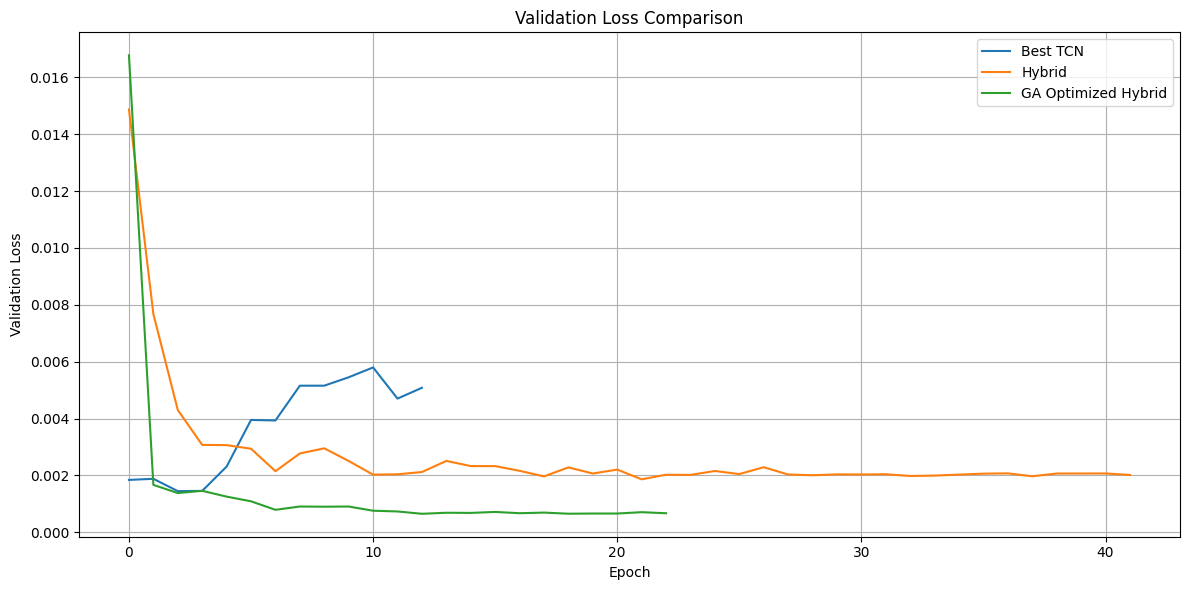

Combined Learning Curve Saved


In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Removed history_lstm as it is not defined in the current state
plt.plot(history_tcn_v2.history["val_loss"],label="Best TCN")

plt.plot(history_hybrid.history["val_loss"],label="Hybrid")

# 'history' variable currently holds the GA Optimized Hybrid training history
plt.plot(history.history["val_loss"],label="GA Optimized Hybrid")

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Comparison")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "Combined_Learning_Curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Combined Learning Curve Saved")

In [ ]:
for model in paper_models:

    pred=predictions[model]

    for i,target in enumerate(["GWETTOP","GWETROOT"]):

        plt.figure(figsize=(6,6))

        plt.scatter(actual[:,i],pred[:,i],alpha=0.5)

        m,b=np.polyfit(actual[:,i],pred[:,i],1)

        plt.plot(
            actual[:,i],
            m*actual[:,i]+b,
            linewidth=2
        )

        plt.xlabel("Actual")

        plt.ylabel("Prediction")

        plt.title(f"{model} Regression ({target})")

        plt.grid(True)

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                RESULT_DIR,
                f"{model.replace(' ','_')}_{target}_Regression.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

print("Regression Plots Saved")

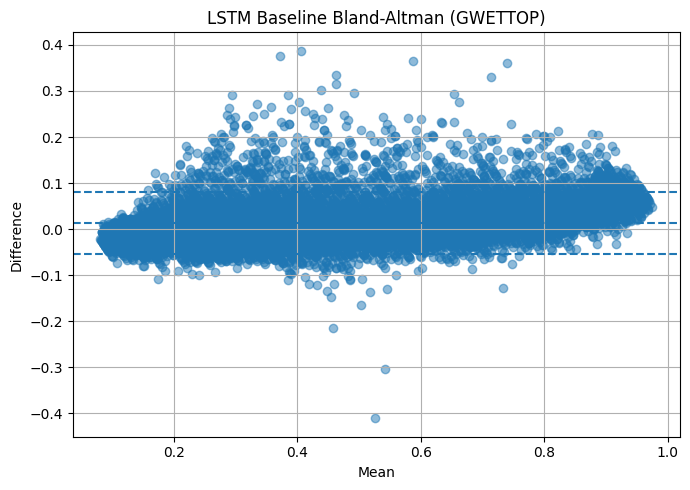

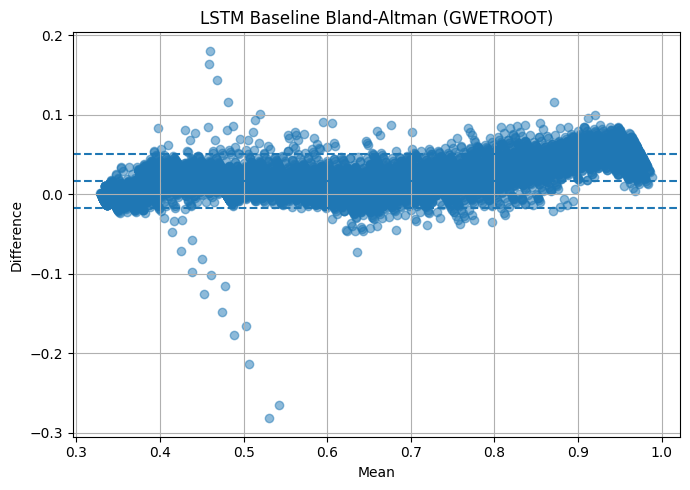

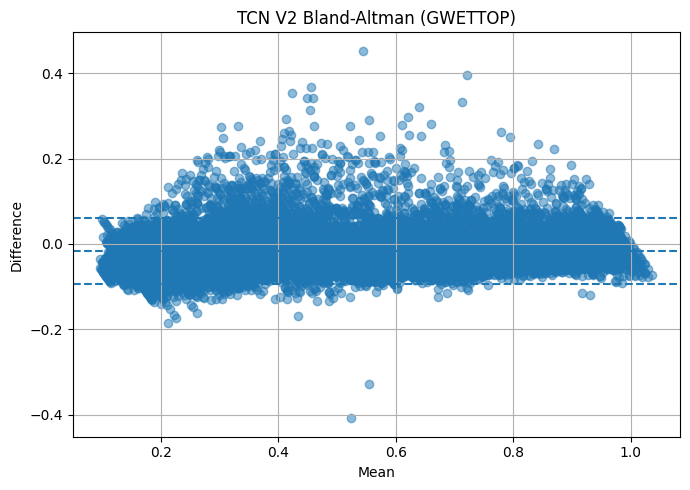

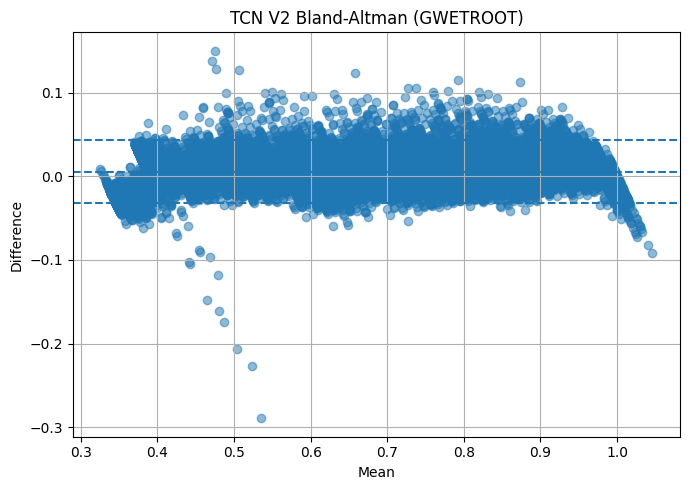

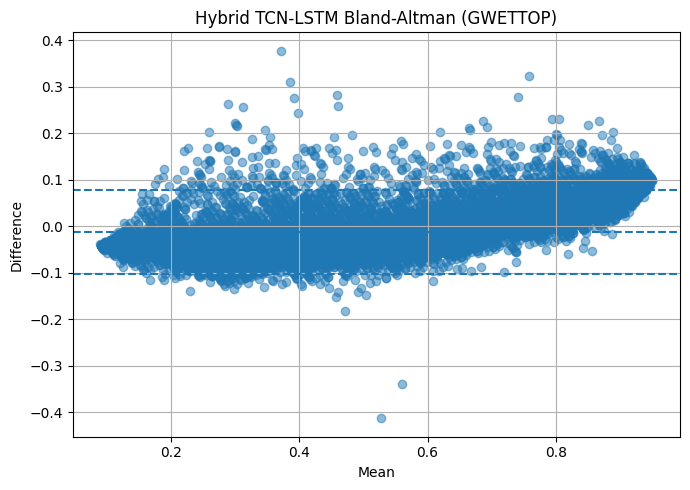

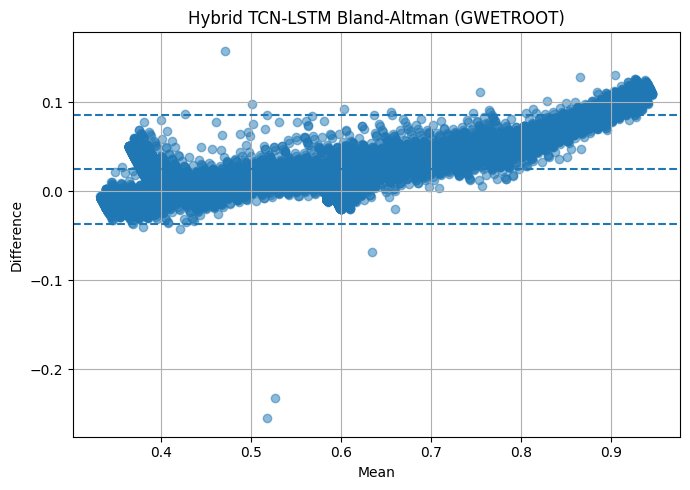

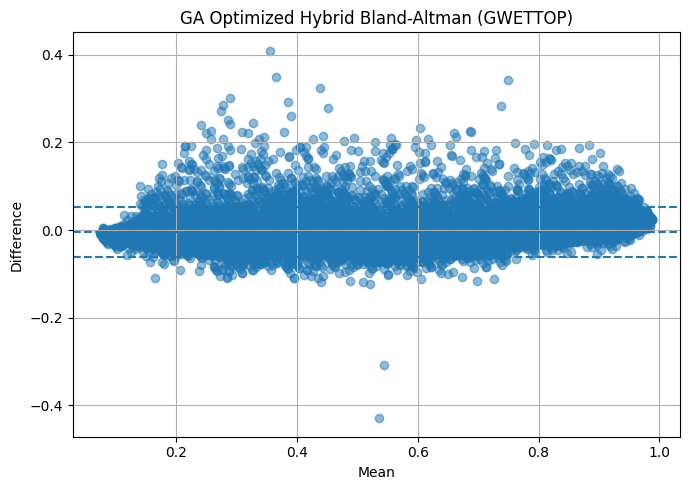

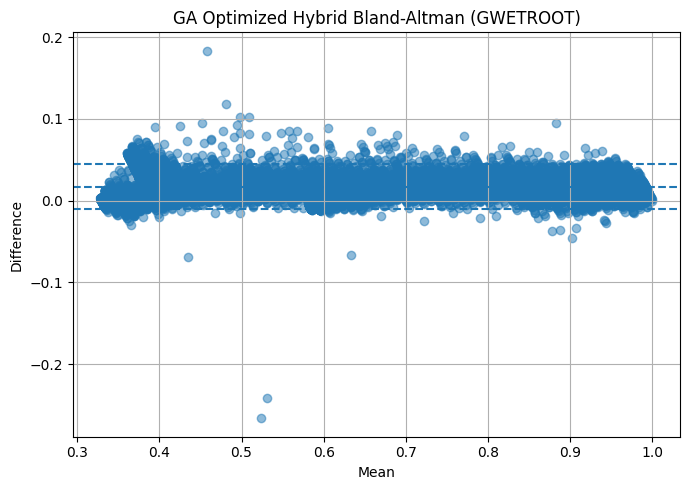

Bland-Altman Plots Saved


In [181]:
for model in paper_models:

    pred=predictions[model]

    for i,target in enumerate(["GWETTOP","GWETROOT"]):

        mean=(actual[:,i]+pred[:,i])/2

        diff=actual[:,i]-pred[:,i]

        md=np.mean(diff)

        sd=np.std(diff)

        plt.figure(figsize=(7,5))

        plt.scatter(mean,diff,alpha=0.5)

        plt.axhline(md,linestyle="--")

        plt.axhline(md+1.96*sd,linestyle="--")

        plt.axhline(md-1.96*sd,linestyle="--")

        plt.xlabel("Mean")

        plt.ylabel("Difference")

        plt.title(f"{model} Bland-Altman ({target})")

        plt.grid(True)

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                RESULT_DIR,
                f"{model.replace(' ','_')}_{target}_BlandAltman.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

print("Bland-Altman Plots Saved")

In [182]:
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import shap

    print("SHAP Found")

    sample = X_test[:200]

    explainer = shap.Explainer(models["GA Optimized Hybrid"], sample)

    shap_values = explainer(sample)

    plt.figure(figsize=(10,6))

    shap.plots.bar(shap_values,show=False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULT_DIR,
            "SHAP_Feature_Importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

except Exception as e:

    print("SHAP not available")

    print(e)

SHAP Found
SHAP not available
The passed model is not callable and cannot be analyzed directly with the given masker! Model: GA_Optimized_Hybrid.keras


In [191]:
!pip install skill_metrics

ERROR: Could not find a version that satisfies the requirement skill_metrics (from versions: none)
ERROR: No matching distribution found for skill_metrics


In [183]:
try:

    import skill_metrics as sm

    import numpy as np

    ref=actual[:,0]

    plt.figure(figsize=(8,8))

    for model in paper_models:

        pred=predictions[model][:,0]

        sm.taylor_diagram(
            np.std(pred),
            np.corrcoef(ref,pred)[0,1],
            np.sqrt(np.mean((pred-ref)**2)),
            markerLabel=model
        )

    plt.savefig(
        os.path.join(
            RESULT_DIR,
            "Taylor_Diagram.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

except Exception as e:

    print("Install skill_metrics")

    print(e)

Install skill_metrics
No module named 'skill_metrics'


In [3]:
from graphviz import Digraph
import os

BASE_DIR = "/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project"
RESULT_DIR = os.path.join(BASE_DIR, "Results")

dot = Digraph('GA_Hybrid_Model', format='png')

dot.attr(rankdir='LR', fontsize='12')

dot.node('A','Input\n(30 Time Steps)')
dot.node('B','TCN Layers')
dot.node('C','LSTM Layer')
dot.node('D','Dropout')
dot.node('E','Dense Layer')
dot.node('F','Output\nGWETTOP & GWETROOT')

dot.edges([
    ('A','B'),
    ('B','C'),
    ('C','D'),
    ('D','E'),
    ('E','F')
])

save_path=os.path.join(RESULT_DIR,"Model_Architecture")

dot.render(save_path,cleanup=True)

print("Model Architecture Saved")

Model Architecture Saved


In [184]:
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

stat_results=[]

reference=predictions["GA Optimized Hybrid"][:,0]

for model in paper_models:

    if model=="GA Optimized Hybrid":

        continue

    pred=predictions[model][:,0]

    t,p1=ttest_rel(reference,pred)

    try:

        w,p2=wilcoxon(reference,pred)

    except:

        w,p2=np.nan,np.nan

    stat_results.append({

        "Model":model,

        "Paired_t_pvalue":p1,

        "Wilcoxon_pvalue":p2

    })

stat_df=pd.DataFrame(stat_results)

display(stat_df)

stat_df.to_csv(

    os.path.join(

        RESULT_DIR,

        "Statistical_Test.csv"

    ),

    index=False

)

stat_df.to_excel(

    os.path.join(

        RESULT_DIR,

        "Statistical_Test.xlsx"

    ),

    index=False

)

print("Statistical Tests Saved")

,Model,Paired_t_pvalue,Wilcoxon_pvalue
0,LSTM Baseline,0.0,0.0
1,TCN V2,0.0,0.0
2,Hybrid TCN-LSTM,0.0,0.0


Statistical Tests Saved


In [188]:
ablation=paper_table.copy()

ablation["Rank_GWETTOP_R2"] = ablation["R2_GWETTOP"].rank(
    ascending=False,
    method="dense"
)
ablation["Rank_GWETROOT_R2"] = ablation["R2_GWETROOT"].rank(
    ascending=False,
    method="dense"
)

display(ablation)

ablation.to_csv(

    os.path.join(

        RESULT_DIR,

        "Ablation_Study.csv"

    ),

    index=False

)

ablation.to_excel(

    os.path.join(

        RESULT_DIR,

        "Ablation_Study.xlsx"

    ),

    index=False

)

print("Ablation Study Saved")

,MAE_GWETROOT,MAE_GWETTOP,RMSE_GWETROOT,RMSE_GWETTOP,R2_GWETROOT,R2_GWETTOP,MAPE_GWETROOT,MAPE_GWETTOP,Rank_GWETTOP_R2,Rank_GWETROOT_R2
Model,,,,,,,,,,
GA Optimized Hybrid,0.0177,0.0194,0.0219,0.0296,0.9856,0.9866,3.3324,5.0175,1.0,2.0
Hybrid TCN-LSTM,0.0291,0.0404,0.0397,0.0475,0.9529,0.9655,4.6218,11.7955,4.0,4.0
LSTM Baseline,0.0186,0.0252,0.0242,0.0365,0.9825,0.9796,3.1575,6.3040,2.0,3.0
TCN V2,0.0155,0.0323,0.0199,0.0422,0.9882,0.9727,3.0428,10.0005,3.0,1.0


Ablation Study Saved


,Model,Inference_Time(sec/sample),Parameters
0,LSTM Baseline,0.014871,128866
1,TCN V2,0.034036,360674
2,Hybrid TCN-LSTM,0.026176,1644194
3,GA Optimized Hybrid,0.020326,1084674


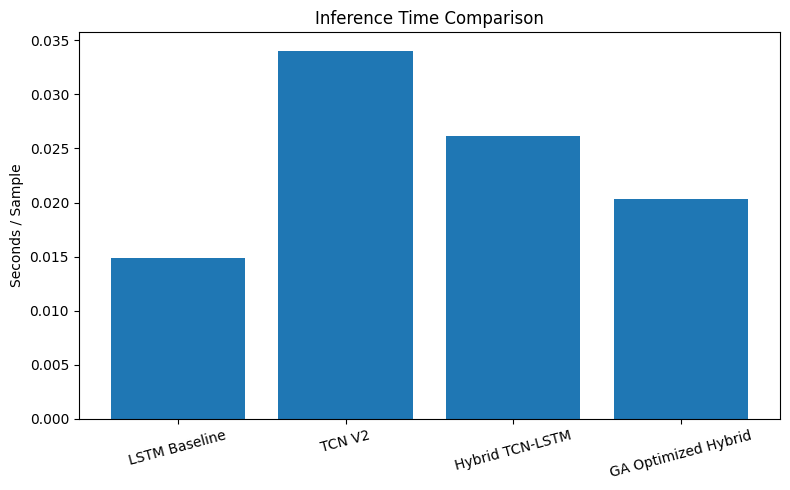

Inference Analysis Saved


In [190]:
import time
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from tcn import TCN # Ensure TCN is imported if needed for custom_objects

summary = []

for model_name_key in paper_models: # Iterate through the display names of the models
    filename = models[model_name_key] # Get the corresponding filename from the 'models' dict
    model_path = os.path.join(MODEL_DIR, filename)

    # Load the model with custom objects if necessary
    mdl = load_model(
        model_path,
        custom_objects={
            "TCN": TCN,
            "mse": MeanSquaredError()
        },
        compile=False # Set compile=False if only using for prediction
    )

    start = time.time()

    # Predict using the sequence data
    mdl.predict(
        X_test_seq[:100], # Use X_test_seq for prediction
        verbose=0
    )

    end = time.time()

    inference = (end - start) / 100

    params = mdl.count_params()

    summary.append({
        "Model": model_name_key,
        "Inference_Time(sec/sample)": inference,
        "Parameters": params
    })

speed = pd.DataFrame(summary)

display(speed)

speed.to_csv(
    os.path.join(
        RESULT_DIR,
        "Model_Speed.csv"
    ),
    index=False
)

speed.to_excel(
    os.path.join(
        RESULT_DIR,
        "Model_Speed.xlsx"
    ),
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    speed["Model"],
    speed["Inference_Time(sec/sample)"]
)

plt.xticks(rotation=15)

plt.ylabel("Seconds / Sample")

plt.title("Inference Time Comparison")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "Inference_Time.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Inference Analysis Saved")

In [4]:
from graphviz import Digraph
import os

flow=Digraph('System',format='png')

flow.attr(rankdir='TB')

flow.node('A','NASA POWER\nWeather Data')

flow.node('B','Preprocessing')

flow.node('C','Feature Engineering')

flow.node('D','TCN-LSTM Model')

flow.node('E','GA Optimization')

flow.node('F','Soil Moisture Prediction')

flow.node('G','Decision Engine')

flow.node('H','LoRa Gateway')

flow.node('I','Raspberry Pi')

flow.node('J','Motor Controller')

flow.node('K','Dashboard')

flow.edges([
('A','B'),
('B','C'),
('C','D'),
('D','E'),
('E','F'),
('F','G'),
('G','H'),
('H','I'),
('I','J'),
('I','K')
])

flow.render(
    os.path.join(
        RESULT_DIR,
        "System_Flowchart"
    ),
    cleanup=True
)

print("Flowchart Saved")

Flowchart Saved


NameError: name 'paper_results' is not defined

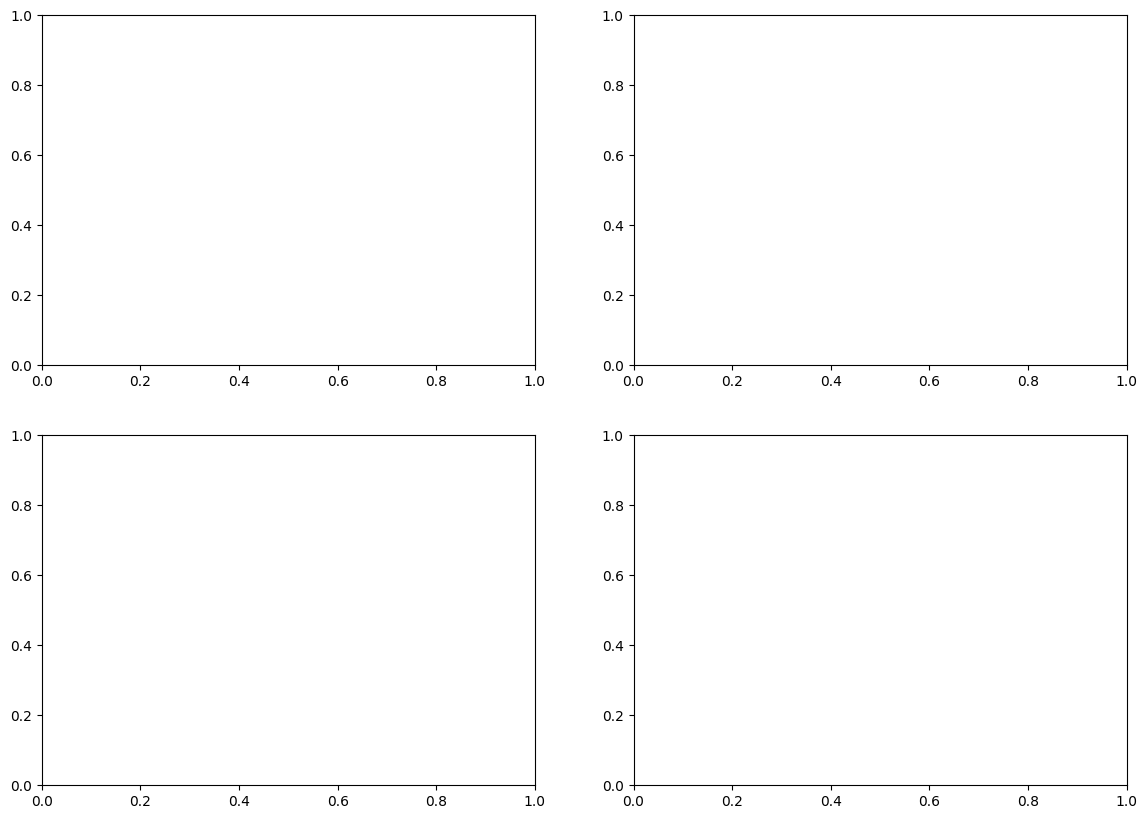

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Redefine paper_models and paper_results for this cell's scope
paper_models = [
    "LSTM Baseline",
    "TCN V2",
    "Hybrid TCN-LSTM",
    "GA Optimized Hybrid"
]

paper_results = results_df[
    results_df["Model"].isin(paper_models)
]

metrics=["MAE","RMSE","R2","MAPE"]

fig,axs=plt.subplots(2,2,figsize=(14,10))

axs=axs.flatten()

for ax,metric in zip(axs,metrics):

    pivot=paper_results.pivot(
        index="Model",
        columns="Target",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(metric)

    ax.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "Final_Performance_Summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Final Summary Figure Saved")

In [6]:
import shutil
import os

zip_path=shutil.make_archive(

    os.path.join(BASE_DIR,"Complete_Results"),

    'zip',

    RESULT_DIR

)

print("="*60)

print("ZIP FILE CREATED")

print(zip_path)

print("="*60)

ZIP FILE CREATED
/content/drive/.shortcut-targets-by-id/1adYf6Uu5YJvCx5ZkHlUYg8OX4d_KflEw/TCN_Irrigation_Project/Complete_Results.zip


In [8]:
from datetime import datetime
import os

# Assuming BASE_DIR and RESULT_DIR are defined in a preceding cell
# If not, they would need to be included here as well
# Example: BASE_DIR = "/content/drive/.shortcut-targets-by-id/YOUR_FOLDER_ID/TCN_Irrigation_Project"
# Example: RESULT_DIR = os.path.join(BASE_DIR, "Results")

# Redefine paper_models for this cell
paper_models = [
    "LSTM Baseline",
    "TCN V2",
    "Hybrid TCN-LSTM",
    "GA Optimized Hybrid"
]

report=open(

    os.path.join(
        RESULT_DIR,
        "Publication_Report.txt"
    ),

    "w"
)

report.write("AI Smart Irrigation Digital Twin\n")

report.write("="*60+"\n")

report.write("Generated : "+str(datetime.now())+"\n\n")

report.write("Models Compared:\n")

for m in paper_models:

    report.write("- "+m+"\n")

report.write("\nEvaluation Metrics:\n")

report.write("- MAE\n")

report.write("- RMSE\n")

report.write("- R2\n")

report.write("- MAPE\n")

report.write("\nFigures Generated:\n")

for file in sorted(os.listdir(RESULT_DIR)):

    if file.endswith(".png"):

        report.write(file+"\n")

report.close()

print("Publication Report Saved")

Publication Report Saved
